# PAM Rodeo noise stats & plots

Reads the merged science CSV and PAM spectrum parquet produced by `glider_data_explore.ipynb`,
bins the science variables, and builds the per-mode/per-bin noise comparison plots. Run
`glider_data_explore.ipynb` first.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import os
import json

import config
from noise_utils import make_bin_edges, plot_corr_matrix, plot_spectrum_lines, plot_box_by_group, setup_map_axes

glider_id = config.GLIDER_ID
DATA_DIR = config.DATA_DIR
FIGURES_DIR = config.FIGURES_DIR  # created on import by config.py

glider_csv_path = os.path.join(DATA_DIR, f'{glider_id}_merged_science.csv')
spectrum_parquet_path = os.path.join(DATA_DIR, f'{glider_id}_pam_spectrum.parquet')

glider_sci_df = pd.read_csv(glider_csv_path)
glider_sci_df['DateTime'] = pd.to_datetime(glider_sci_df['DateTime'])
print(f'Loaded {len(glider_sci_df):,} rows from {glider_csv_path}')

# glider_data_explore.ipynb never drops depth_mask_flag rows, so keep an unfiltered copy here
# specifically for the QC diagnostic map (which needs the flagged rows to actually show them),
# then apply config.QC_APPLIED to the working copy used for every other plot/analysis below.
glider_sci_df_unfiltered = glider_sci_df.copy()
if config.QC_APPLIED:
    n_before = len(glider_sci_df)
    glider_sci_df = glider_sci_df[glider_sci_df['depth_mask_flag'] == 0].reset_index(drop=True)
    print(f'QC applied: dropped {n_before - len(glider_sci_df):,} flagged rows, '
          f'{len(glider_sci_df):,} rows remain for analysis')

pam_spectrum_df = pd.read_parquet(spectrum_parquet_path)
pam_spectrum_df['DateTime'] = pd.to_datetime(pam_spectrum_df['DateTime'])
hybrid_cols = [c for c in pam_spectrum_df.columns if c.startswith('hybridMiliDecLevels_')]
hybrid_freqs = np.array([float(c.replace('hybridMiliDecLevels_', '').replace('Hz', '')) for c in hybrid_cols])
freq_order = np.argsort(hybrid_freqs)
hybrid_cols = [hybrid_cols[i] for i in freq_order]
hybrid_freqs = hybrid_freqs[freq_order]
print(f'Loaded {len(hybrid_cols)} hybrid millidecade bands from {spectrum_parquet_path}')

# chronological mode order, derived straight from the data (first time each phase appears) -
# avoids needing to re-read phase_key_df.xlsx here. Modes in config.EXCLUDED_MODES (e.g.
# 'recovery', which barely has any data) are dropped from every per-mode plot/analysis below,
# but still count toward the whole-deployment (all-modes-combined) stats.
mode_order = glider_sci_df.sort_values('DateTime')['phase'].dropna().drop_duplicates().tolist()
mode_order = [m for m in mode_order if m not in config.EXCLUDED_MODES]

cmap = plt.get_cmap('tab20')
mode_colors = {m: cmap(i / max(len(mode_order) - 1, 1)) for i, m in enumerate(mode_order)}

print(f'{len(mode_order)} mission phases (after exclusions):', mode_order)

Loaded 128,395 rows from ./noise_analysis_outputs\sg607\data\sg607_merged_science.csv
QC applied: dropped 3,559 flagged rows, 124,836 rows remain for analysis
Loaded 2797 hybrid millidecade bands from ./noise_analysis_outputs\sg607\data\sg607_pam_spectrum.parquet
9 mission phases (after exclusions): ['shakedown', 'fast', 'shallow dives', 'slow', 'intermediate', 'drift', 'mini-slow', 'mini-intermediate', 'mini-fast']


In [2]:
# Bin each science variable into fixed-width ranges (native units) for the per-mode
# spectrum/box comparisons below. Bin edges are computed once globally (not per mode) so
# a given bin means the same thing across every mode's plot. Widths (config.BIN_WIDTHS)
# are rough defaults - adjust in config.py to taste for this deployment's actual data range.
BIN_VARS = config.BIN_VARS
BIN_WIDTHS = config.BIN_WIDTHS

bin_edges = {}
for var in BIN_VARS:
    edges = make_bin_edges(glider_sci_df[var], BIN_WIDTHS[var])
    bin_edges[var] = edges
    glider_sci_df[f'{var}_bin'] = pd.cut(glider_sci_df[var], bins=edges, right=False)

for var in BIN_VARS:
    n_bins = len(bin_edges[var]) - 1
    print(f'{var}: {n_bins} bins from {bin_edges[var][0]:g} to {bin_edges[var][-1]:g}')

temperature: 3 bins from 0 to 30
salinity: 3 bins from 34 to 35.5
density: 3 bins from 1022 to 1028
soundVelocity: 12 bins from 1480 to 1540
depth: 12 bins from -100 to 1100
latitude: 8 bins from 21.15 to 21.55
longitude: 8 bins from -158.45 to -158.05


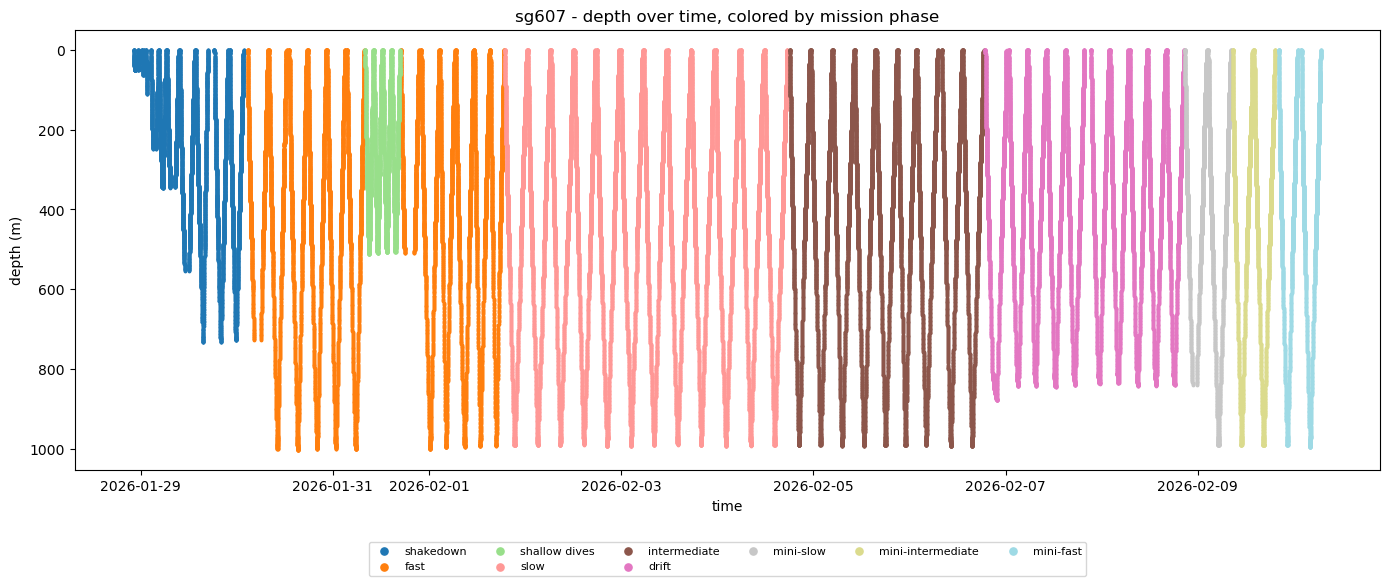

In [3]:
# Full-mission depth-over-time overview, colored by mission phase
fig, ax = plt.subplots(figsize=(14, 6))
for mode in mode_order:
    sub = glider_sci_df[glider_sci_df['phase'] == mode]
    ax.scatter(sub['DateTime'], sub['depth'], s=3, color=mode_colors[mode], label=mode)

ax.invert_yaxis()
ax.set_xlabel('time')
ax.set_ylabel('depth (m)')
ax.set_title(f'{glider_id} - depth over time, colored by mission phase')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6, fontsize=8, markerscale=3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_time_depth_by_mode.png'), dpi=150, bbox_inches='tight')
plt.show()

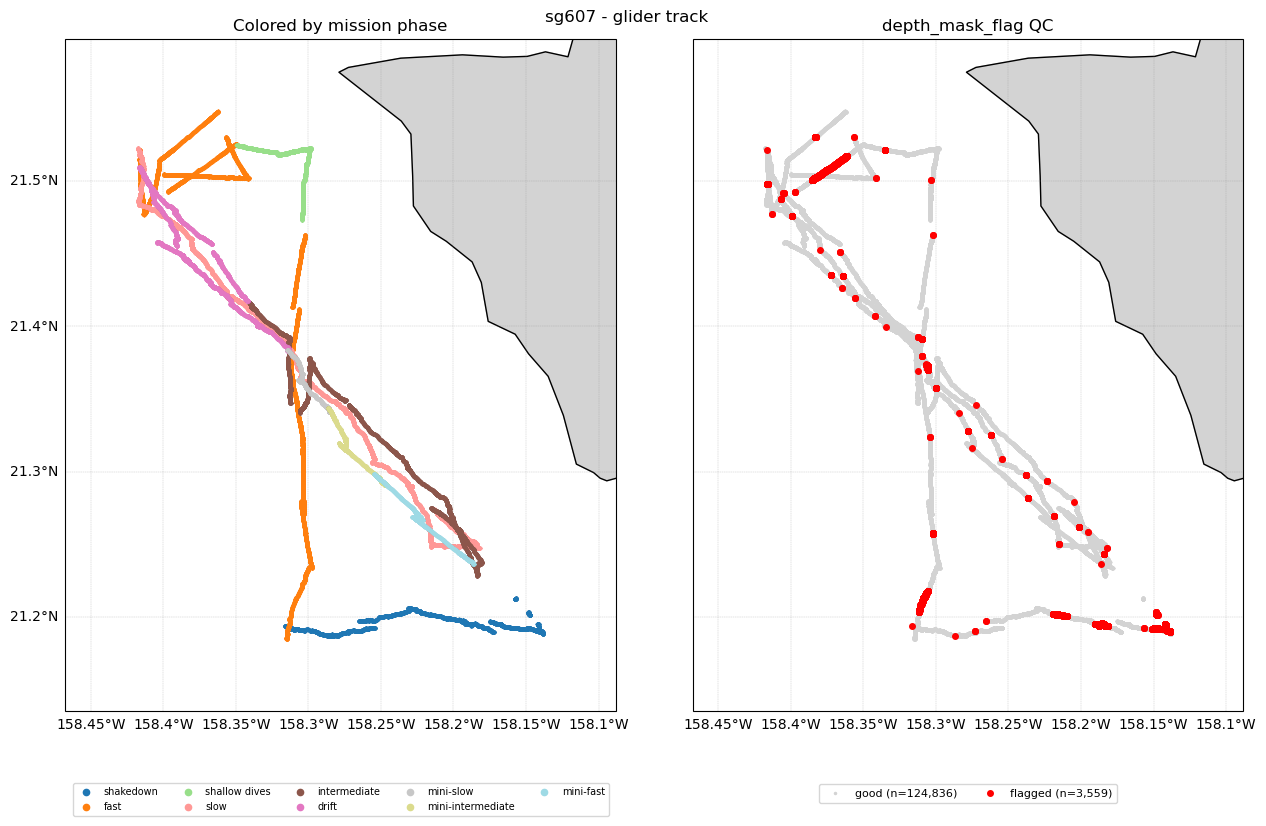

In [4]:
# Full-mission glider track on a real map (cartopy, PlateCarree): left colored by mission
# phase, right showing where depth_mask_flag flagged bad data. Both panels use
# glider_sci_df_unfiltered (not the possibly-QC-filtered glider_sci_df) so the QC panel always
# has flagged rows to show, even when config.QC_APPLIED has dropped them from the analysis copy.
# Land/coastline/gridline boilerplate lives in noise_utils.setup_map_axes.
# Figure width is sized to the extent's own aspect ratio - cartopy's GeoAxes preserves the
# map's true aspect and centers it in whatever box it's given, so a figsize that doesn't match
# leaves big blank margins on both sides of each map (that's what looked like a wide gap
# between panels, not actual subplot spacing - wspace alone can't fix that).
lons, lats = glider_sci_df_unfiltered['longitude'], glider_sci_df_unfiltered['latitude']
pad = 0.05
extent = [lons.min() - pad, lons.max() + pad, lats.min() - pad, lats.max() + pad]

lon_range = extent[1] - extent[0]
lat_range = extent[3] - extent[2]
panel_height = 8
panel_width = panel_height * (lon_range / lat_range)

fig = plt.figure(figsize=(2 * panel_width, panel_height))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree(), sharey=ax0)

setup_map_axes(ax0, extent)
setup_map_axes(ax1, extent, left_labels=False)

for mode in mode_order:
    sub = glider_sci_df_unfiltered[glider_sci_df_unfiltered['phase'] == mode]
    ax0.plot(sub['longitude'], sub['latitude'], '.', markersize=3, color=mode_colors[mode],
              label=mode, transform=ccrs.PlateCarree())
ax0.set_title('Colored by mission phase')
ax0.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=7, markerscale=3)

good = glider_sci_df_unfiltered[glider_sci_df_unfiltered['depth_mask_flag'] == 0]
bad = glider_sci_df_unfiltered[glider_sci_df_unfiltered['depth_mask_flag'] == 1]
ax1.plot(good['longitude'], good['latitude'], '.', markersize=3, color='lightgray',
          label=f'good (n={len(good):,})', transform=ccrs.PlateCarree())
ax1.plot(bad['longitude'], bad['latitude'], '.', markersize=8, color='red',
          label=f'flagged (n={len(bad):,})', transform=ccrs.PlateCarree())
ax1.set_title('depth_mask_flag QC')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=8)

fig.suptitle(f'{glider_id} - glider track')
plt.tight_layout()
fig.subplots_adjust(wspace=0.05)
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_track_by_mode.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Attach glider_sci_df's phase + bin labels onto the PAM spectrum via nearest-time match,
# same tolerance approach as the broadband merge in glider_data_explore.ipynb
label_cols = ['phase'] + [f'{var}_bin' for var in BIN_VARS]
labels_subset = glider_sci_df[['DateTime'] + label_cols].dropna(subset=['DateTime']).sort_values('DateTime')

pam_labeled = pd.merge_asof(
    pam_spectrum_df.sort_values('DateTime'),
    labels_subset,
    on='DateTime',
    direction='nearest',
    tolerance=pd.Timedelta('90s'),
)

print(f'{pam_labeled["phase"].notna().sum()} of {len(pam_labeled)} PAM samples got a matching phase label')

15352 of 15876 PAM samples got a matching phase label


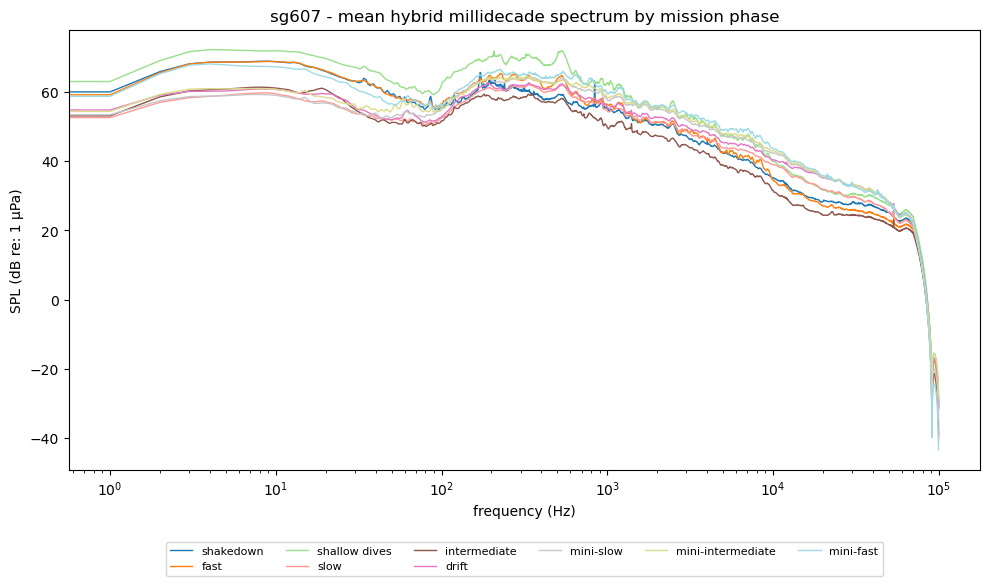

In [6]:
# Mean noise spectrum per mission phase - frequency (log x) vs SPL (dB), one line per mode
spectrum_by_mode = {}
for mode in mode_order:
    sub = pam_labeled[pam_labeled['phase'] == mode]
    if sub.empty:
        continue
    spectrum_by_mode[mode] = sub[hybrid_cols].mean().values

fig, ax = plt.subplots(figsize=(10, 6))
plot_spectrum_lines(hybrid_freqs, spectrum_by_mode, mode_colors,
                     f'{glider_id} - mean hybrid millidecade spectrum by mission phase',
                     ax=ax, legend_ncol=6, legend_fontsize=8, legend_anchor=-0.15)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_spectrum_by_mode.png'), dpi=150, bbox_inches='tight')
plt.show()

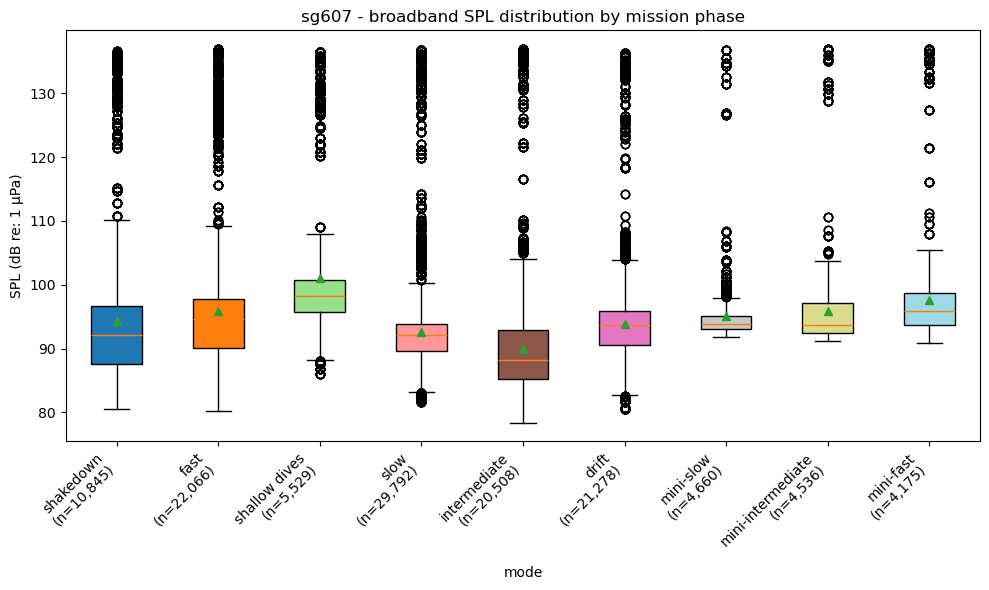

In [7]:
# Broadband SPL distribution by mission phase - one box per mode, no legend (x-axis already labels mode)
broadband_by_mode = {m: glider_sci_df.loc[glider_sci_df['phase'] == m, 'broadband'].dropna() for m in mode_order}

fig, ax = plt.subplots(figsize=(10, 6))
plot_box_by_group(broadband_by_mode, mode_colors, 'mode', 'SPL (dB re: 1 μPa)',
                   f'{glider_id} - broadband SPL distribution by mission phase', ax=ax)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_broadband_boxplot_by_mode.png'), dpi=150, bbox_inches='tight')
plt.show()

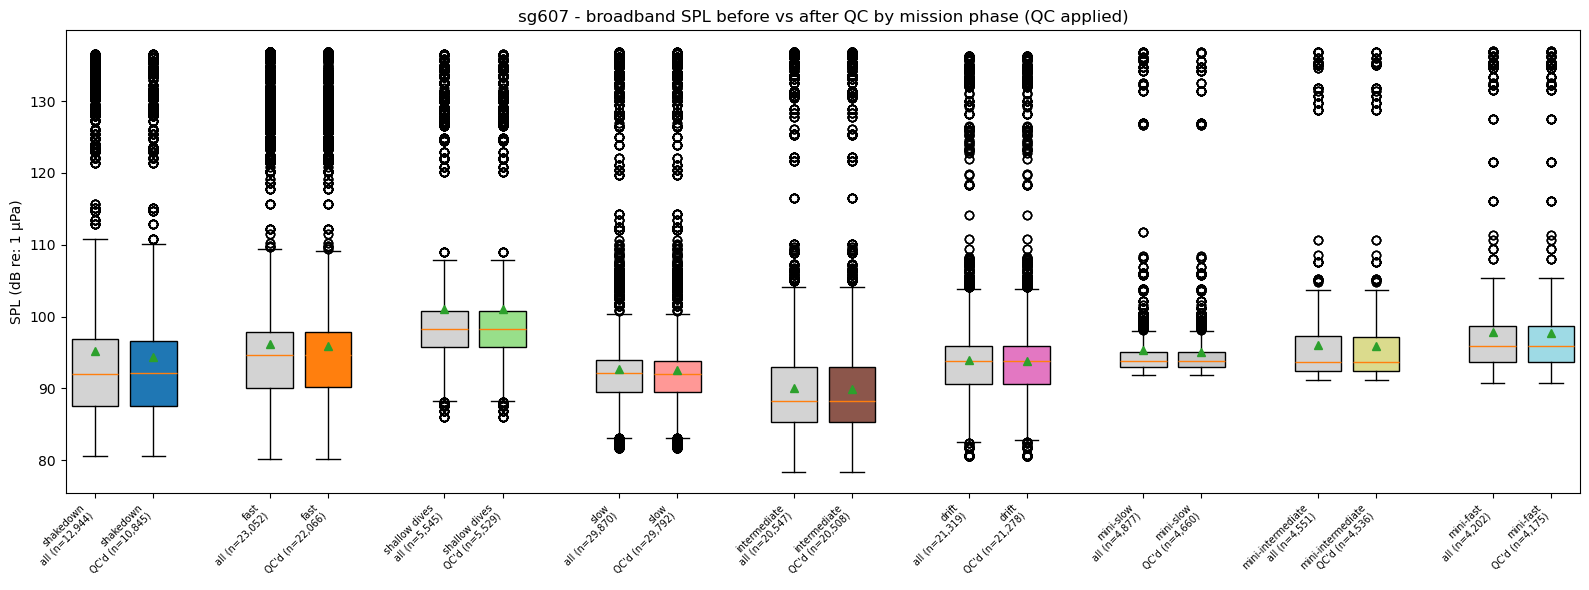

,mode,n_total,n_dropped,pct_dropped,mean_broadband_before,mean_broadband_after,mean_broadband_delta
0,shakedown,12944,2099,16.216007,95.215373,94.362322,-0.853051
1,fast,23052,986,4.277286,96.138492,95.904050,-0.234442
2,shallow dives,5545,16,0.288548,101.117075,101.016245,-0.100830
3,slow,29870,78,0.261132,92.681339,92.574717,-0.106622
4,intermediate,20547,39,0.189809,90.037236,89.956073,-0.081163
5,drift,21319,41,0.192317,93.921552,93.892722,-0.028831
6,mini-slow,4877,217,4.449457,95.308427,95.103599,-0.204829
7,mini-intermediate,4551,15,0.329598,96.058236,95.934658,-0.123577
8,mini-fast,4202,27,0.642551,97.906045,97.665887,-0.240157


In [8]:
# QC impact: broadband SPL before (all data) vs after (config.QC_APPLIED-filtered) depth_mask_flag
# QC, one pair of boxes per mode - same paired before/after box-plot pattern as glider_qc.ipynb.
# When QC_APPLIED is False the two boxes in each pair are identical (nothing was dropped), which
# is the expected/correct degenerate case, not a bug.
qc_impact = []
data, positions, colors, tick_labels = [], [], [], []
pos = 1
for mode in mode_order:
    before = glider_sci_df_unfiltered.loc[glider_sci_df_unfiltered['phase'] == mode, 'broadband'].dropna()
    after = glider_sci_df.loc[glider_sci_df['phase'] == mode, 'broadband'].dropna()

    data.append(before)
    positions.append(pos)
    colors.append('lightgray')
    tick_labels.append(f'{mode}\nall (n={len(before):,})')
    pos += 1

    data.append(after)
    positions.append(pos)
    colors.append(mode_colors[mode])
    tick_labels.append(f'{mode}\nQC\'d (n={len(after):,})')
    pos += 2  # extra gap between mode pairs

    qc_impact.append({
        'mode': mode,
        'n_total': len(before),
        'n_dropped': len(before) - len(after),
        'pct_dropped': 100 * (len(before) - len(after)) / len(before) if len(before) else np.nan,
        'mean_broadband_before': before.mean(),
        'mean_broadband_after': after.mean(),
        'mean_broadband_delta': after.mean() - before.mean(),
    })

fig, ax = plt.subplots(figsize=(16, 6))
bp = ax.boxplot(data, positions=positions, widths=0.8, patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('SPL (dB re: 1 μPa)')
qc_title_suffix = 'QC applied' if config.QC_APPLIED else 'QC not applied - "all" and "QC\'d" boxes match'
ax.set_title(f'{glider_id} - broadband SPL before vs after QC by mission phase ({qc_title_suffix})')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_qc_before_after_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

qc_impact_df = pd.DataFrame(qc_impact)
qc_impact_df

In [9]:
# Overall (whole-mission) Pearson correlation between broadband SPL and each science variable -
# a straightforward "is there a relationship" table using every row directly, not split by mode
# and not aggregated into bins.
overall_corr = []
for var in BIN_VARS:
    raw = glider_sci_df[[var, 'broadband']].dropna()
    if len(raw) >= 2:
        r, p = stats.pearsonr(raw[var], raw['broadband'])
    else:
        r, p = np.nan, np.nan
    overall_corr.append({'var': var, 'r': r, 'p': p, 'n': len(raw)})

overall_corr_df = pd.DataFrame(overall_corr).sort_values('r', key=np.abs, ascending=False).reset_index(drop=True)
overall_corr_df

,var,r,p,n
0,latitude,0.125160,0.000000e+00,123389
1,salinity,0.117079,0.000000e+00,121454
2,density,-0.110499,0.000000e+00,121491
3,soundVelocity,0.107791,1.286231e-310,121454
4,longitude,-0.076340,7.406353e-159,123389
5,temperature,0.052339,1.377652e-75,123389
6,depth,0.021122,1.170232e-13,123389


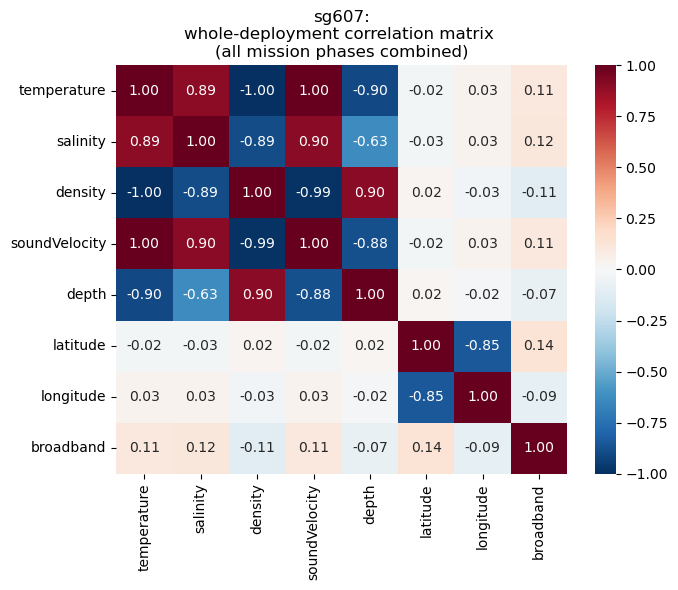

In [10]:
# Whole-deployment correlation matrix - all CTD/science variables + broadband SPL, correlated
# against each other (not just each var vs broadband), computed once across every row with all
# modes combined. Diverging red/blue colormap centered at 0, same pattern as glider_qc.ipynb.
CORR_MATRIX_VARS = BIN_VARS + ['broadband']

fig, ax = plt.subplots(figsize=(7, 6))
overall_corr_matrix = plot_corr_matrix(
    glider_sci_df, CORR_MATRIX_VARS,
    f'{glider_id}:\nwhole-deployment correlation matrix \n(all mission phases combined)', ax)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_overall_corr_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

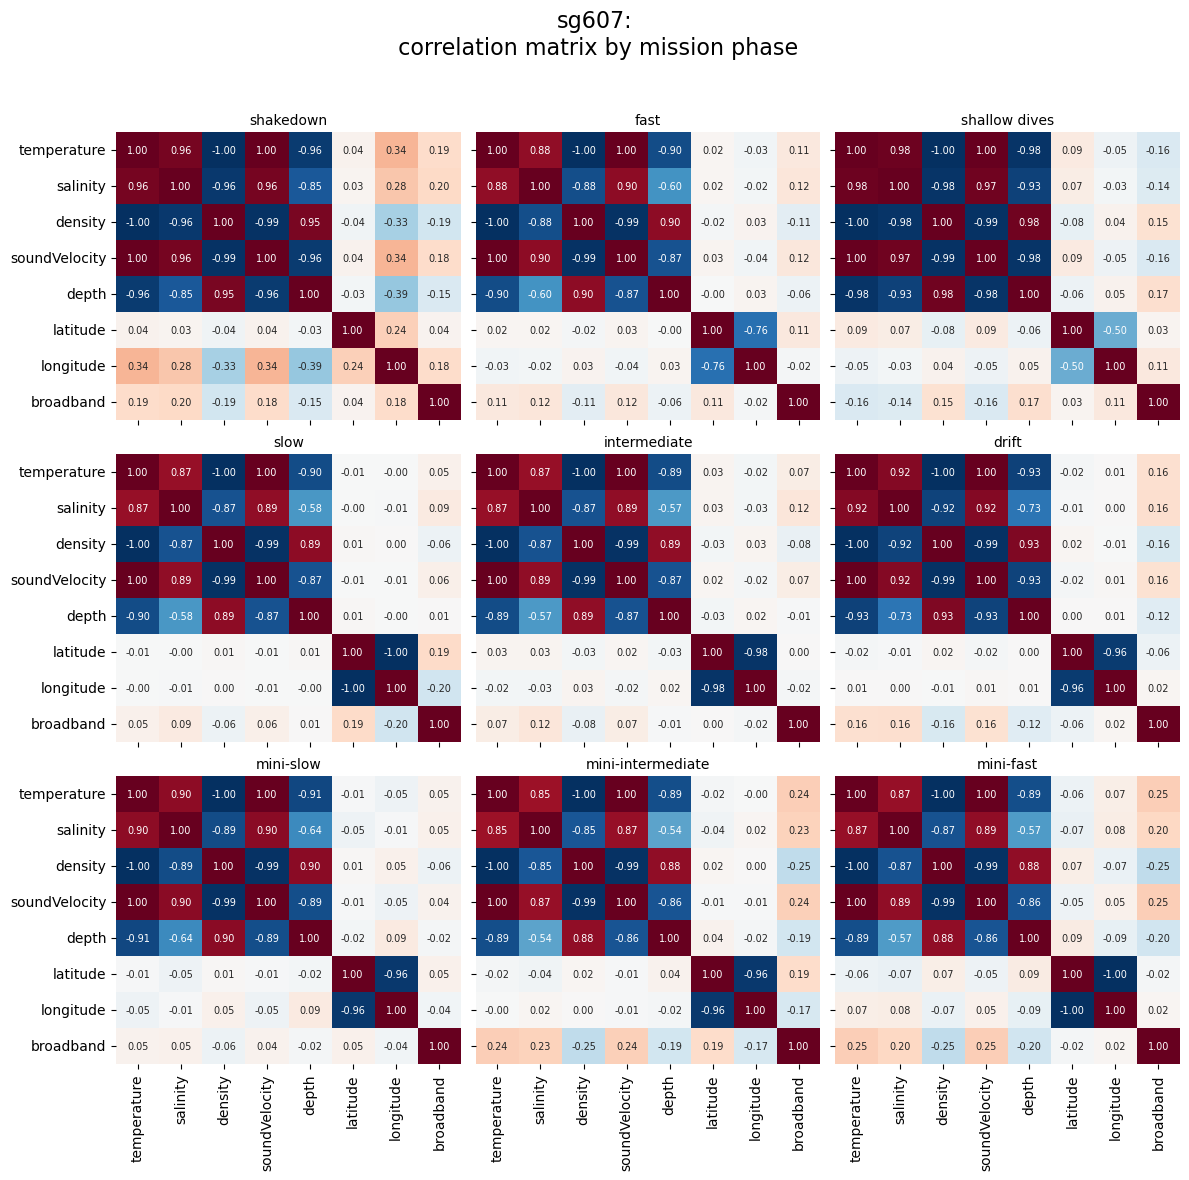

In [11]:
# Per-mode correlation matrix - same variables, computed separately within each mode's subset,
# side by side for direct comparison (e.g. does a temperature-broadband relationship hold in
# every mode, or only during certain flight behaviors?). Every subplot has identical variable
# names on both axes, so sharex/sharey + label_outer() drops the redundant tick labels from
# every panel except the bottom row / left column - only the title and heatmap values differ.
n_cols = 3
n_rows = int(np.ceil(len(mode_order) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharex=True, sharey=True)
axs = np.atleast_2d(axs)

for i, mode in enumerate(mode_order):
    ax = axs[i // n_cols, i % n_cols]
    plot_corr_matrix(glider_sci_df[glider_sci_df['phase'] == mode], CORR_MATRIX_VARS, mode, ax,
                      cbar=False, annot_kws={'size': 7})
    ax.title.set_fontsize(10)
    ax.label_outer()

# hide any unused subplot axes if mode count isn't a clean multiple of n_cols
for j in range(len(mode_order), n_rows * n_cols):
    axs[j // n_cols, j % n_cols].axis('off')

fig.suptitle(f'{glider_id}:\n correlation matrix by mission phase', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_corr_matrix_by_mode.png'), dpi=150, bbox_inches='tight')
plt.show()

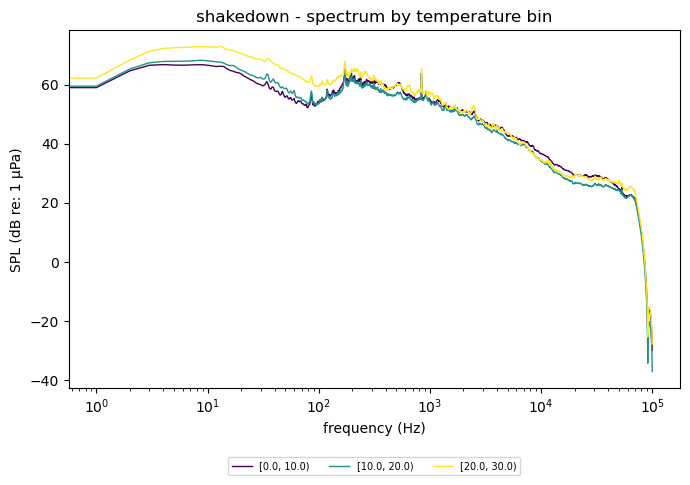

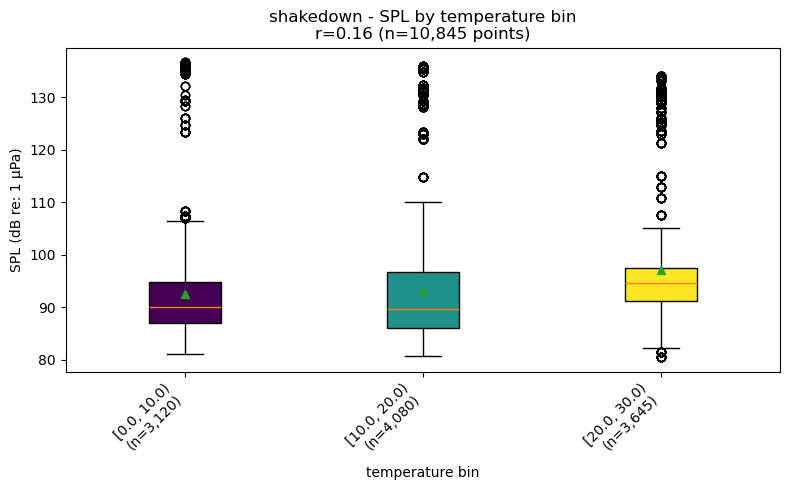

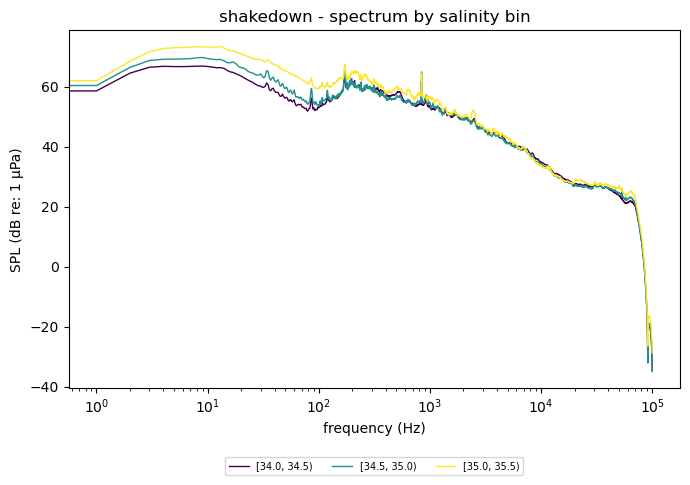

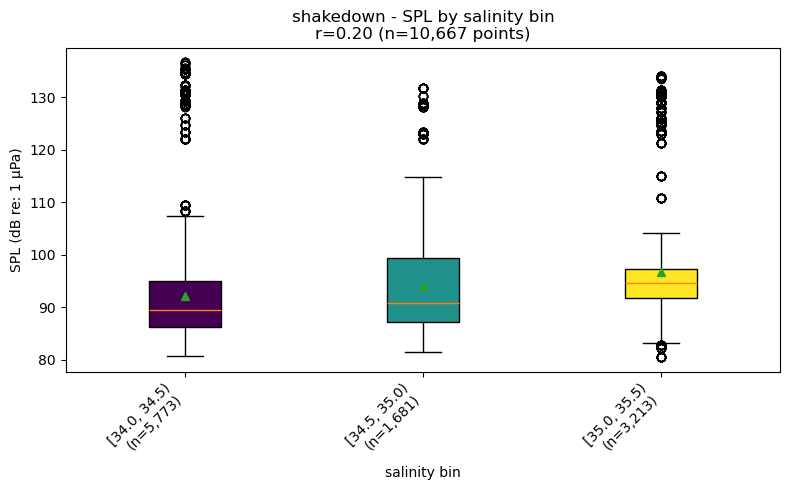

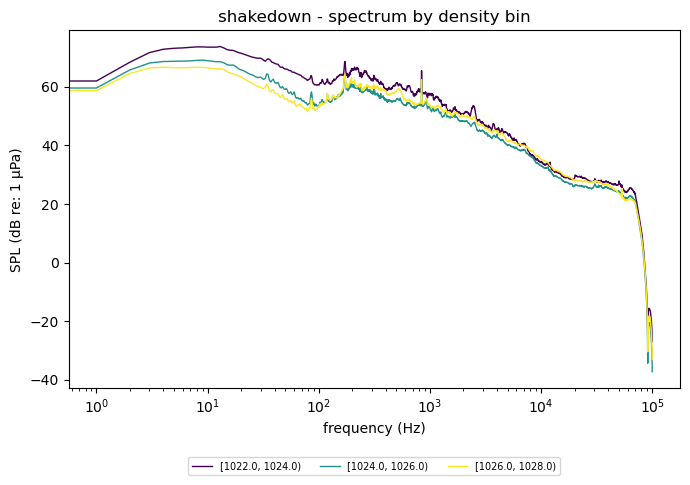

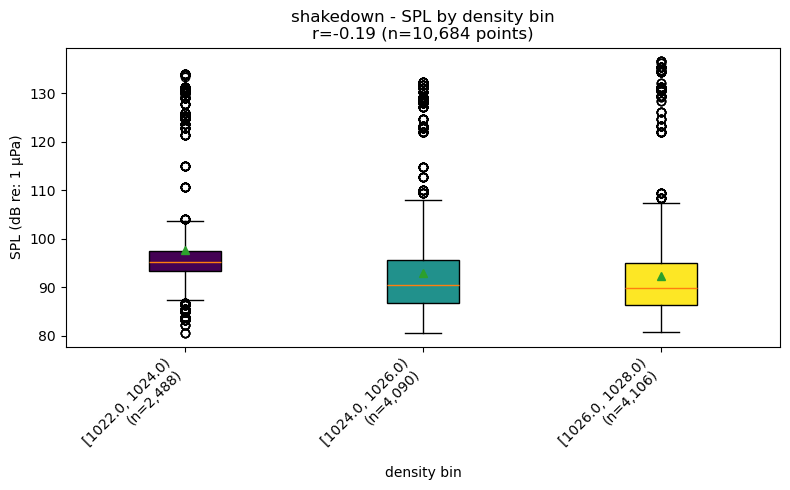

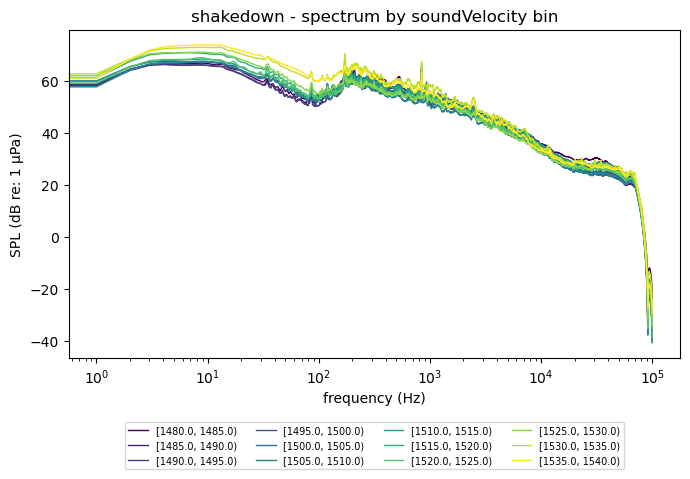

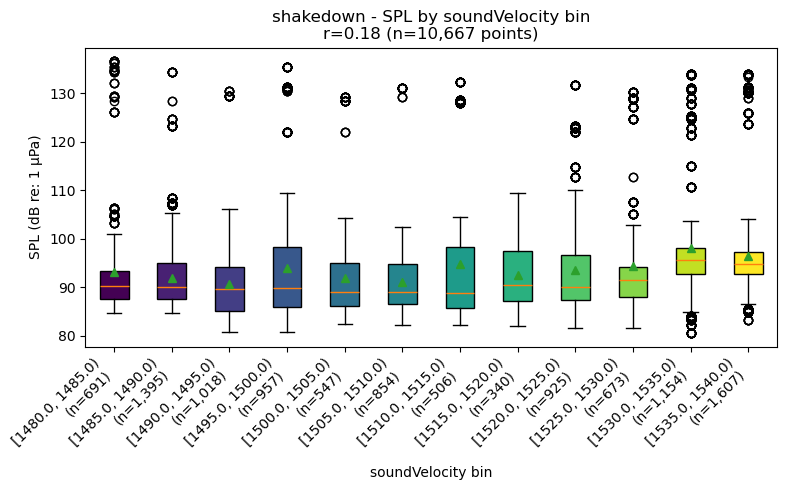

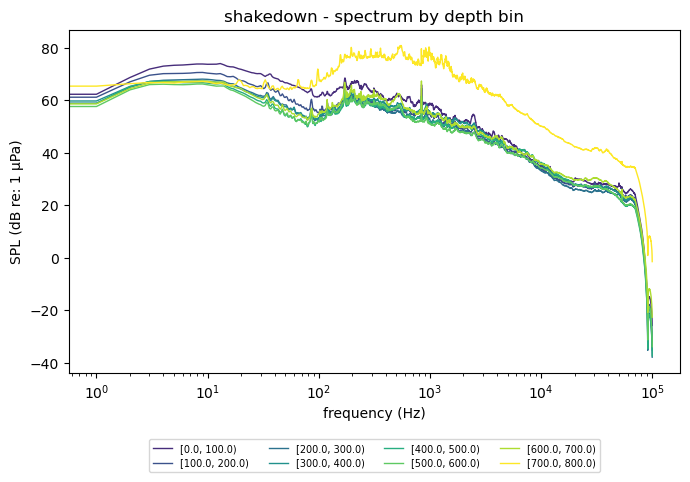

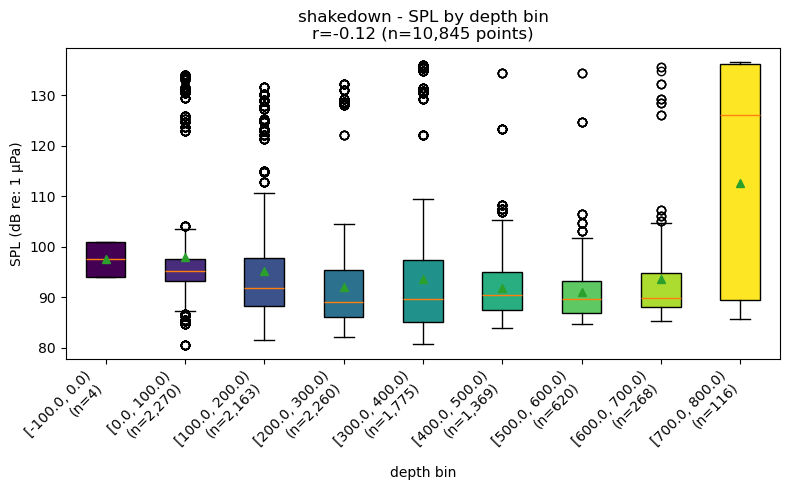

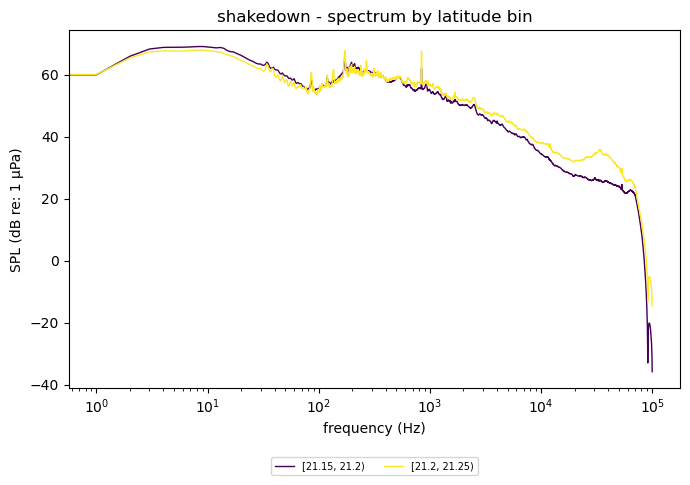

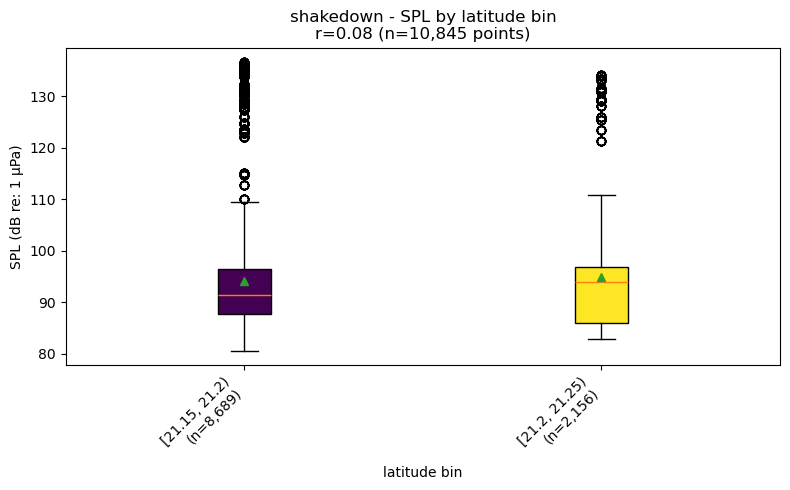

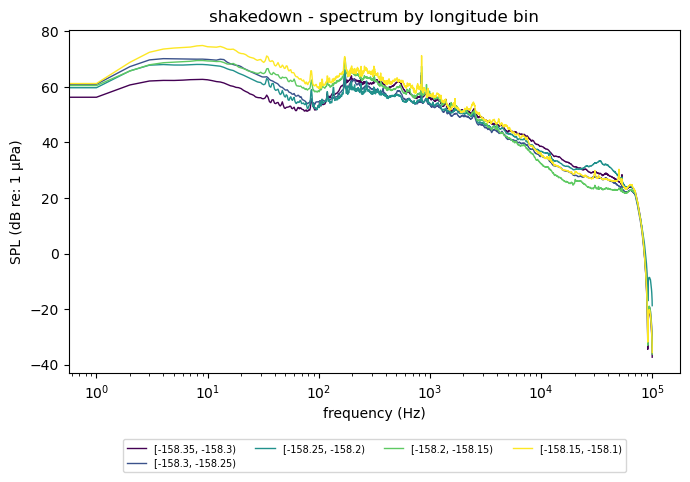

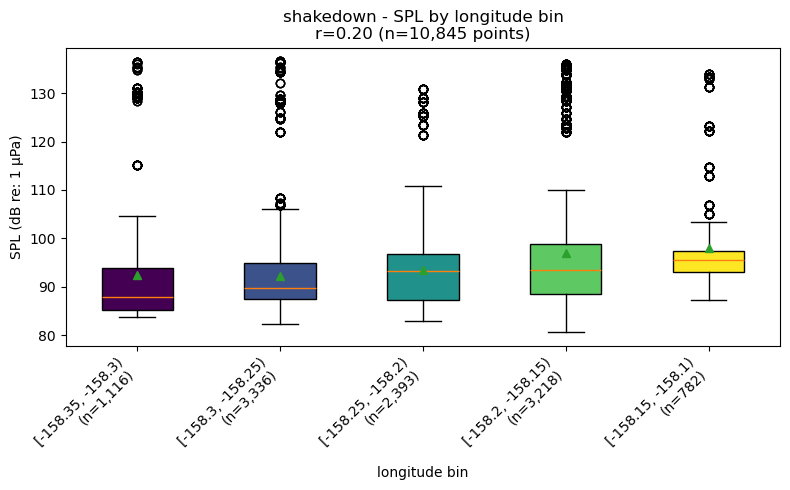

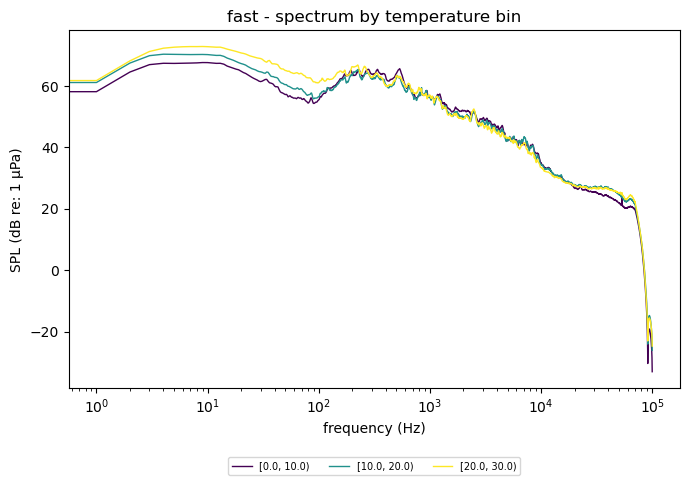

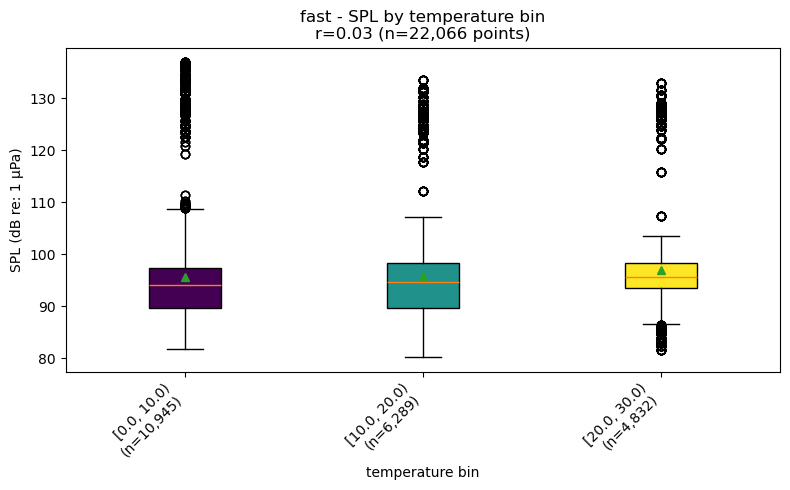

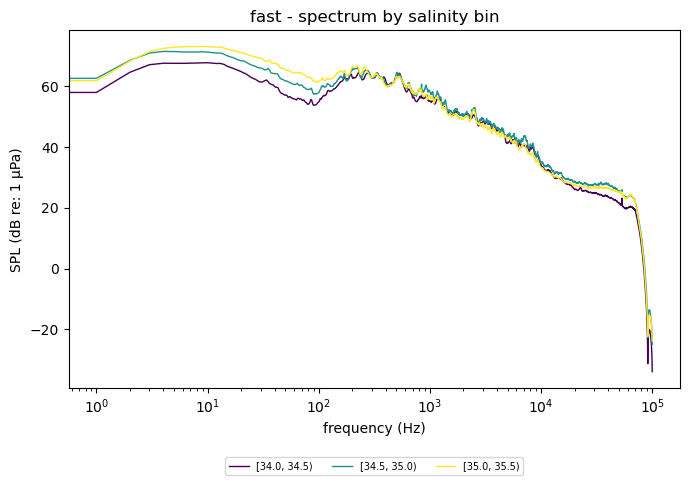

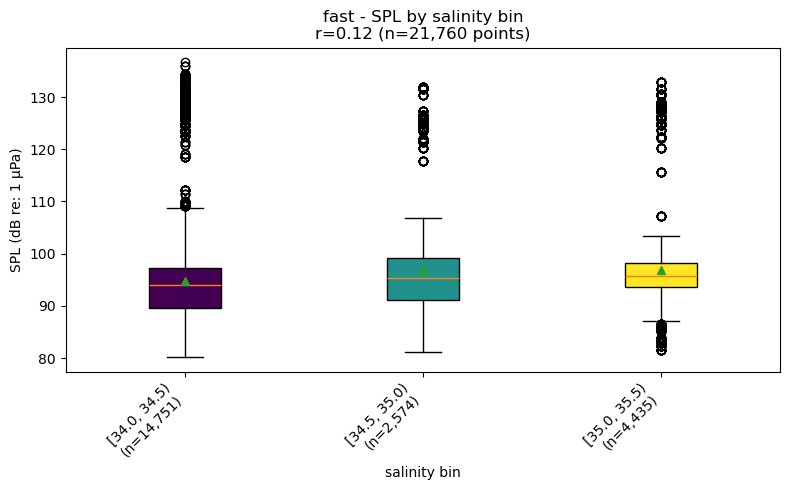

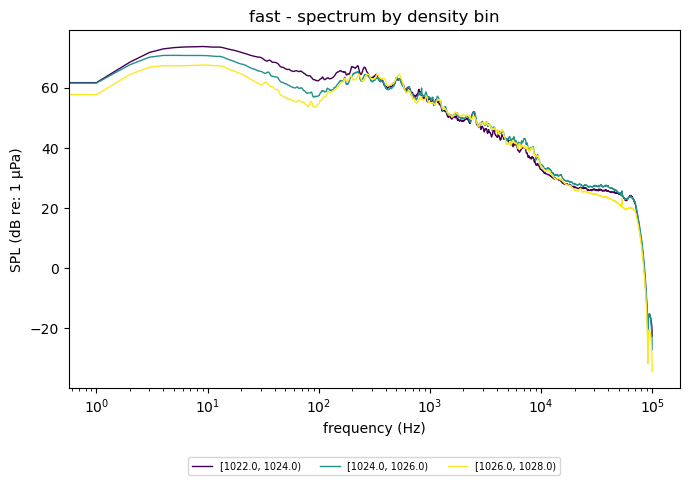

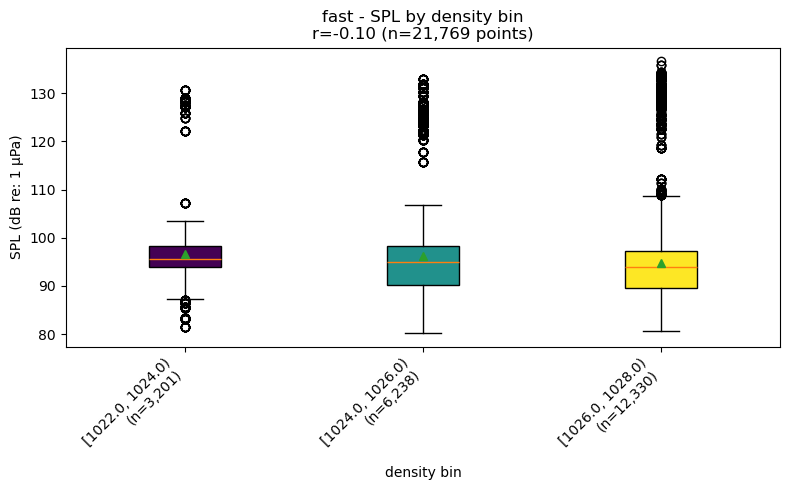

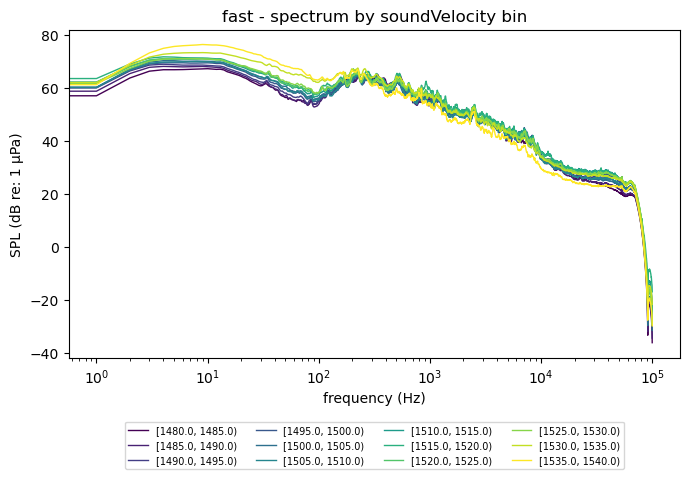

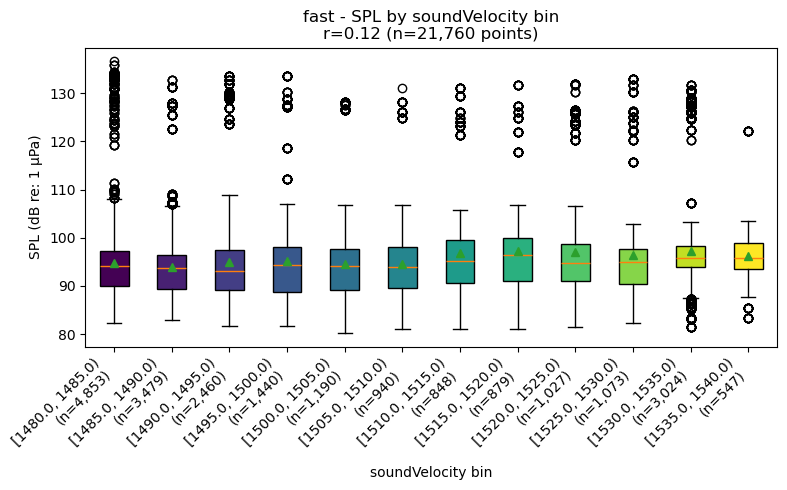

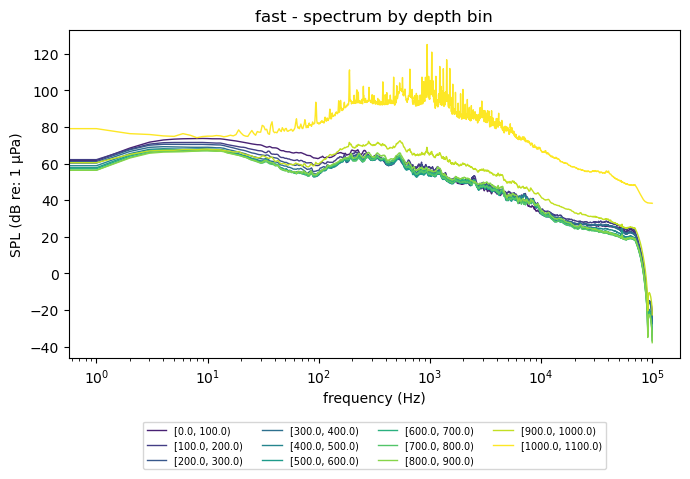

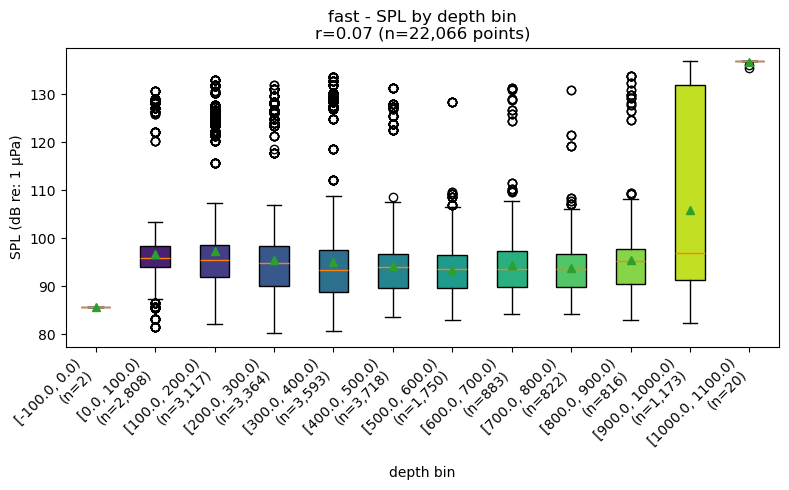

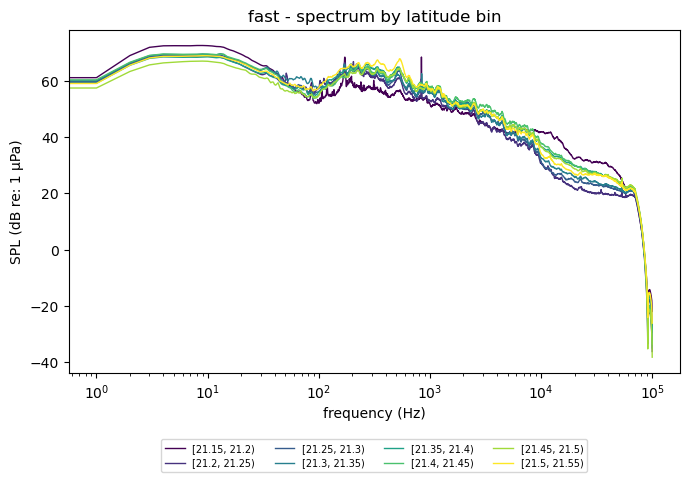

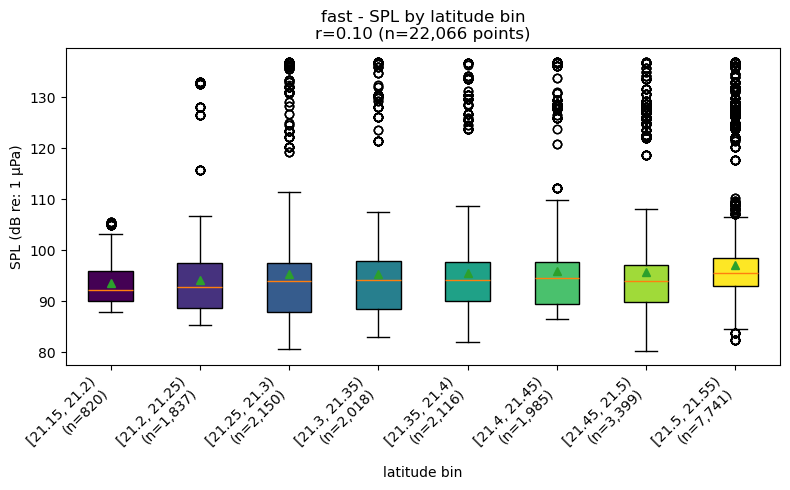

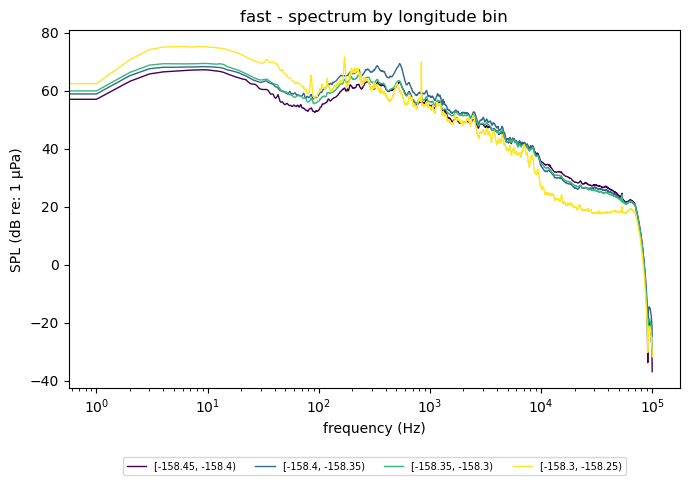

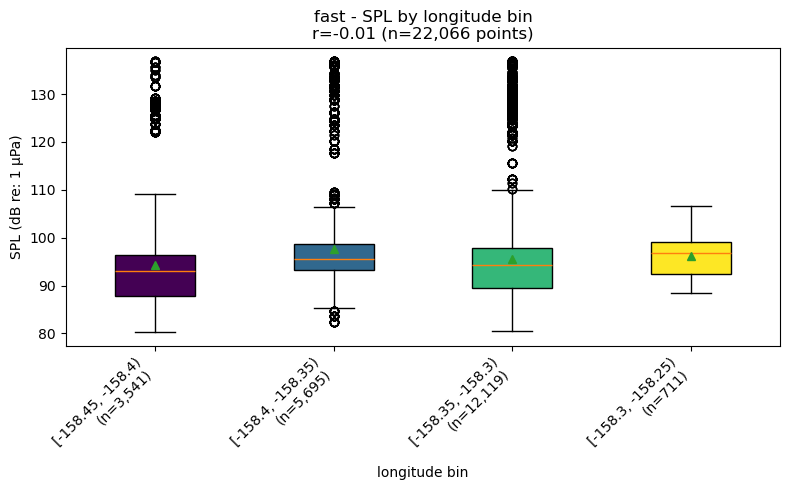

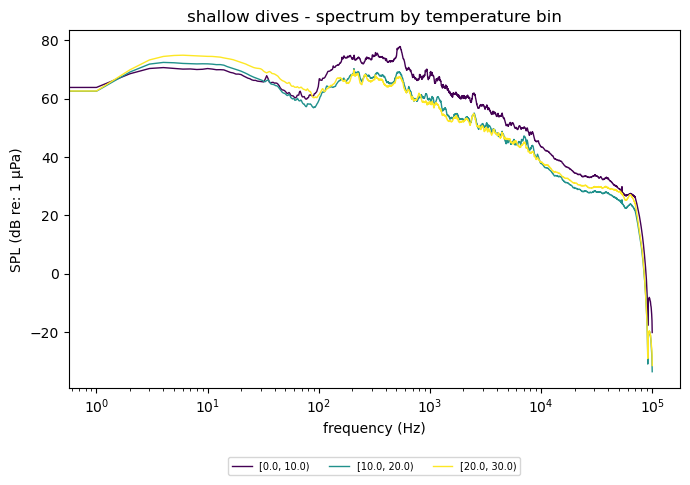

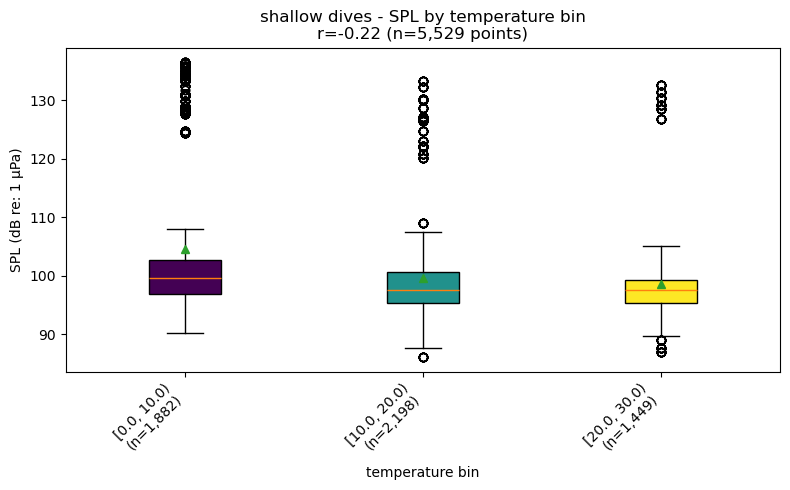

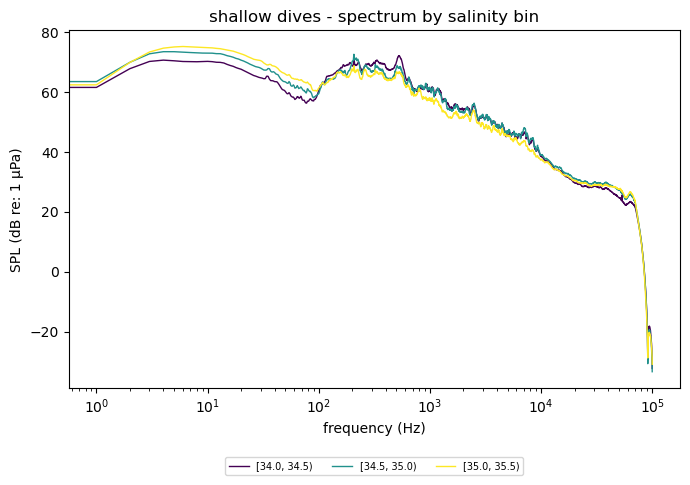

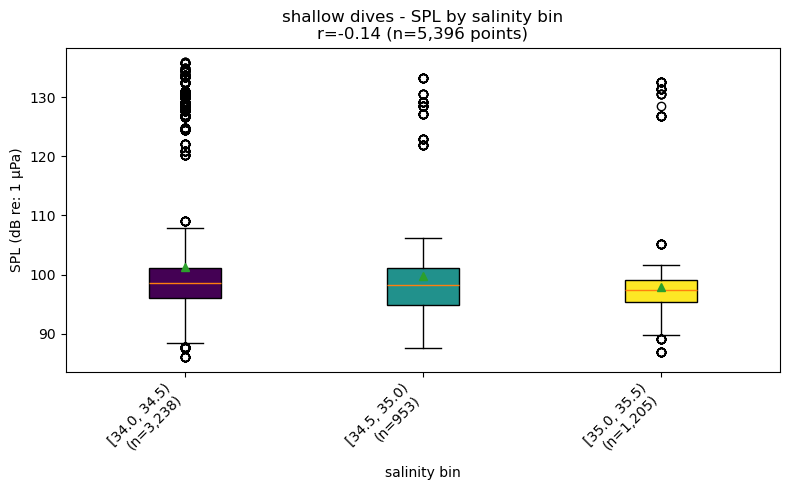

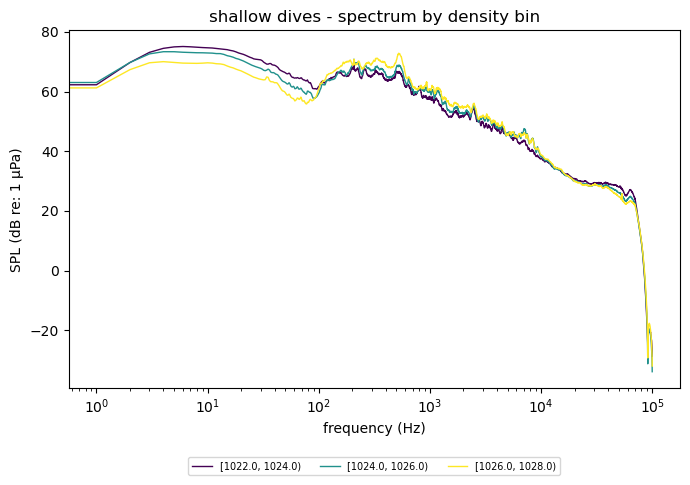

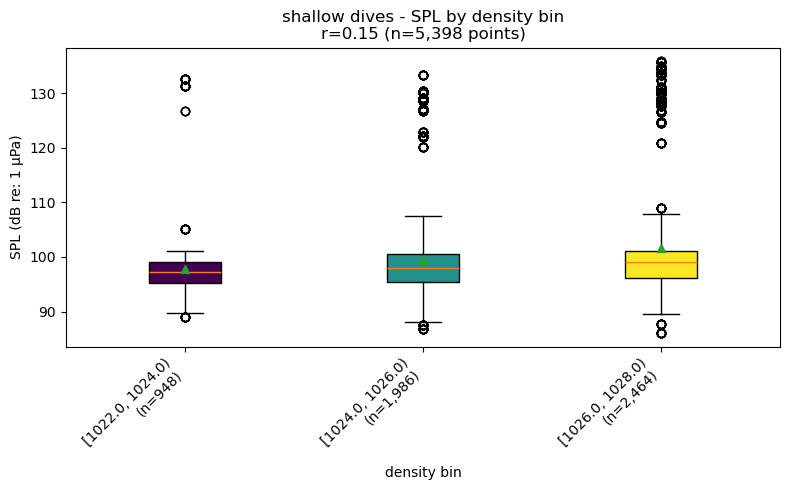

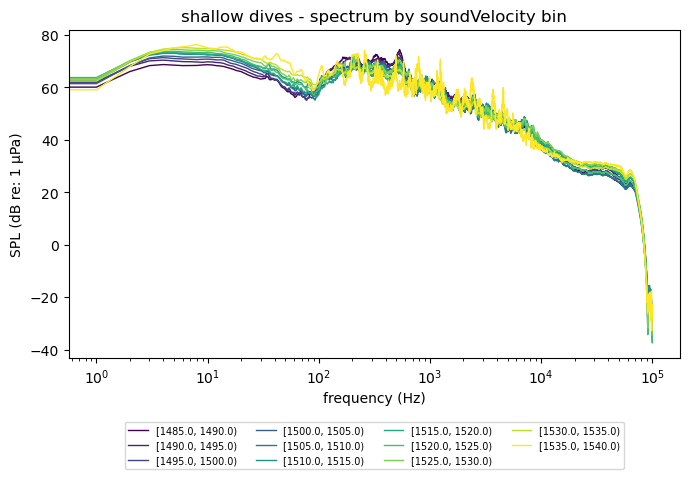

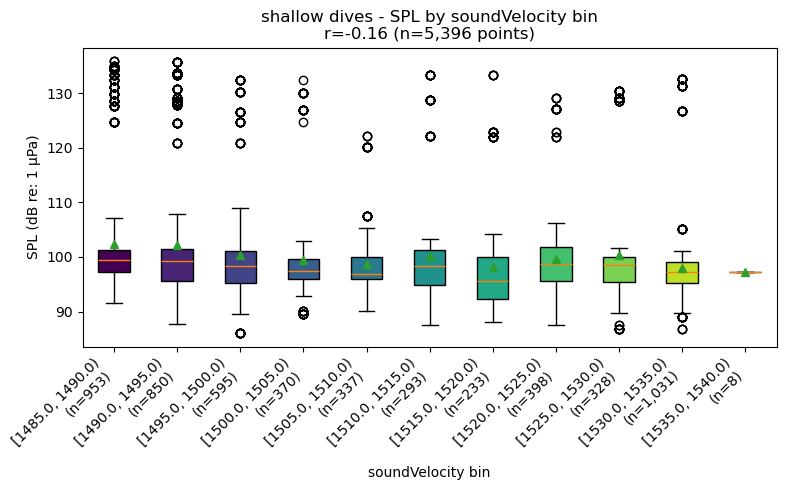

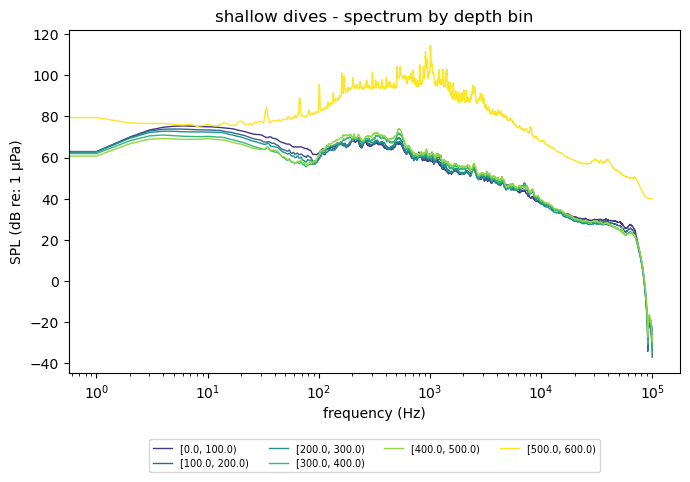

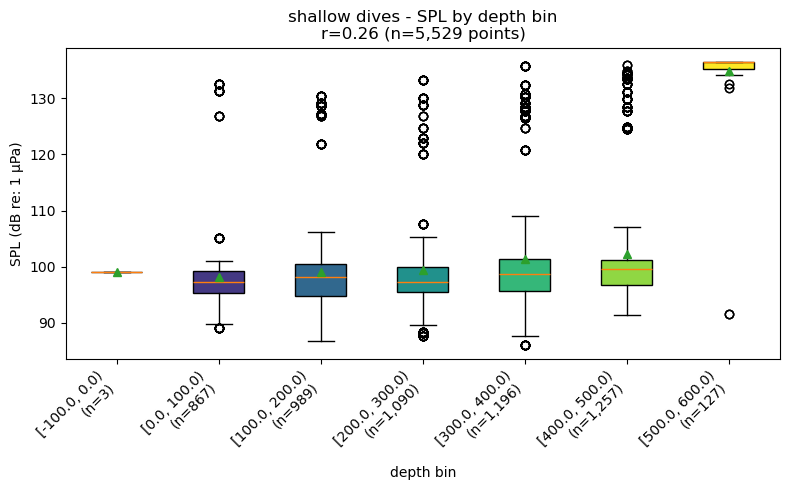

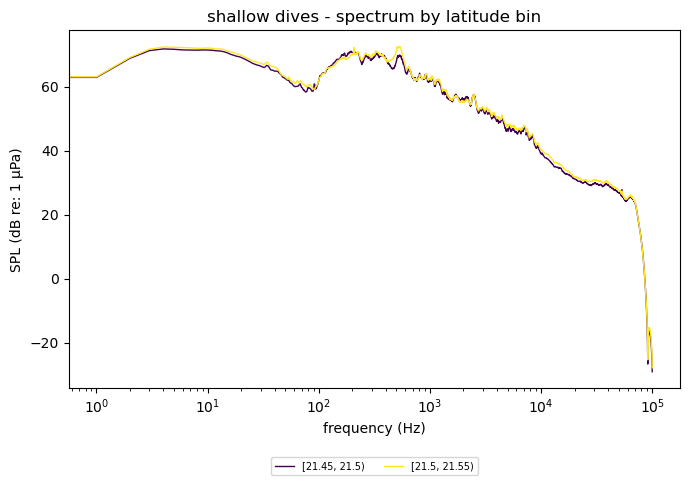

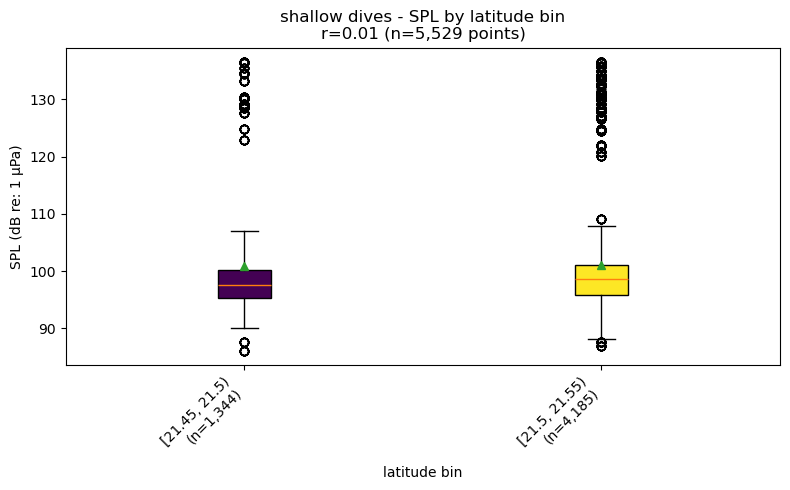

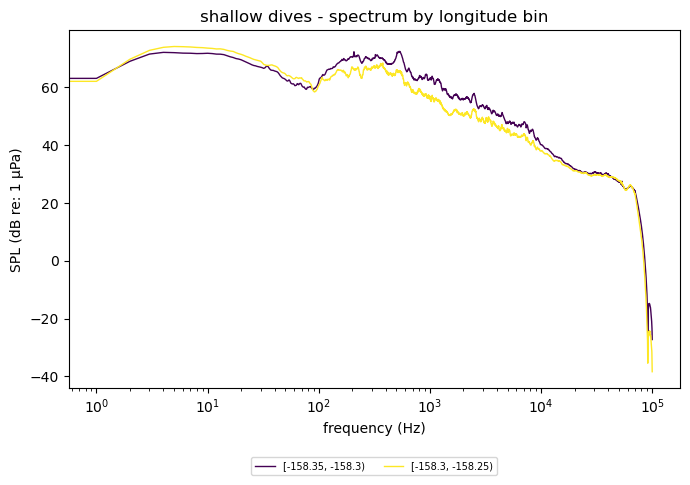

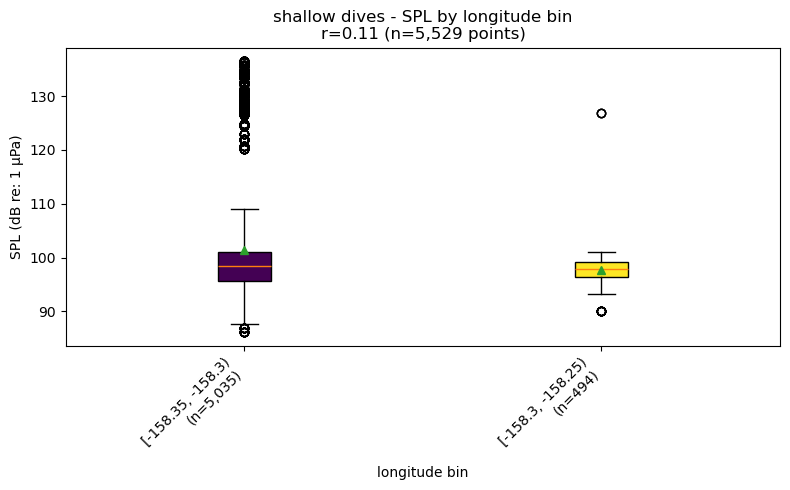

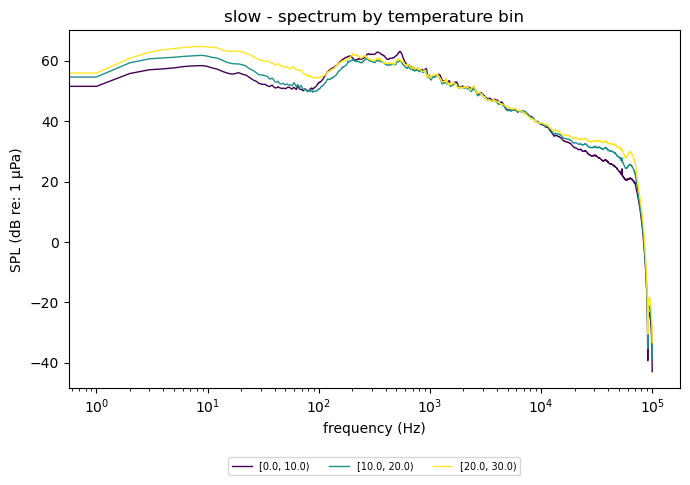

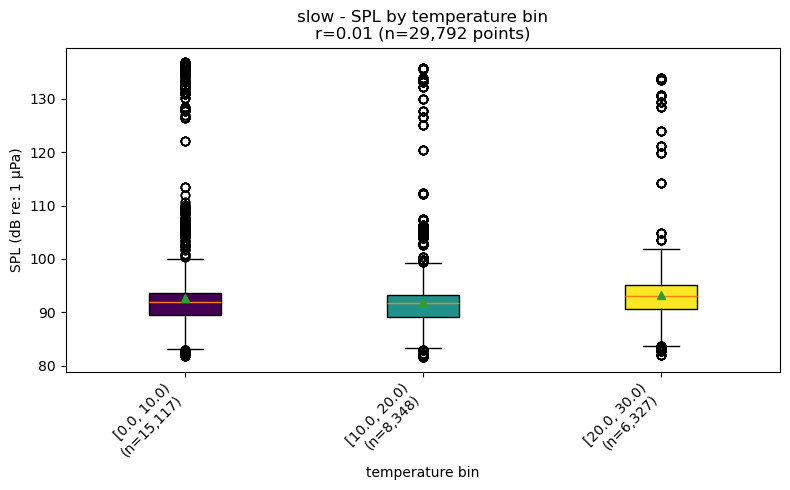

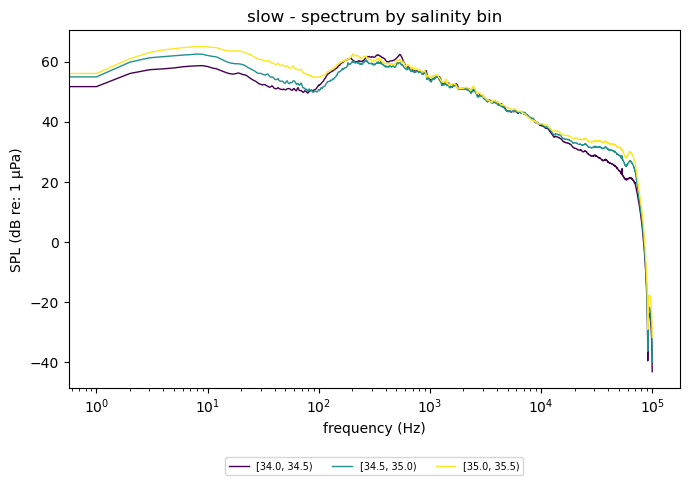

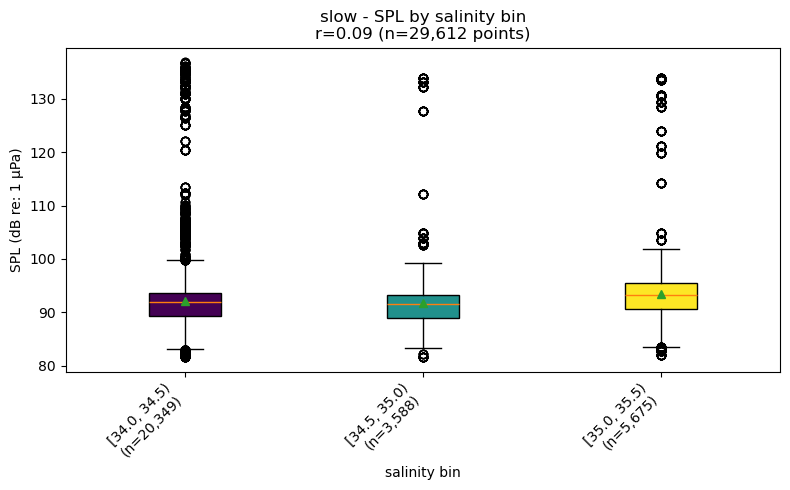

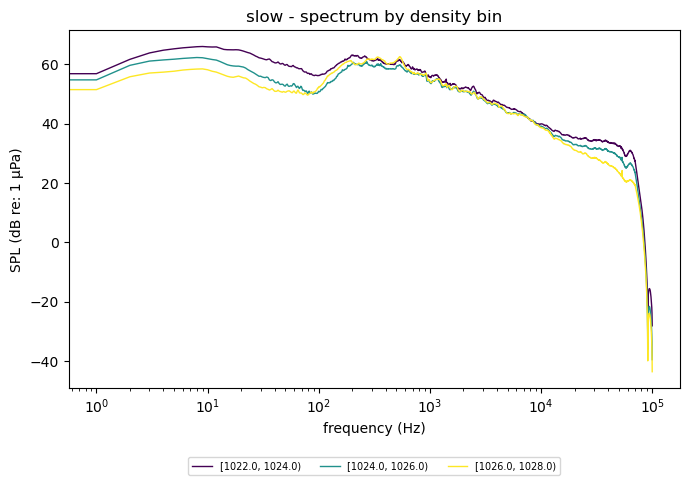

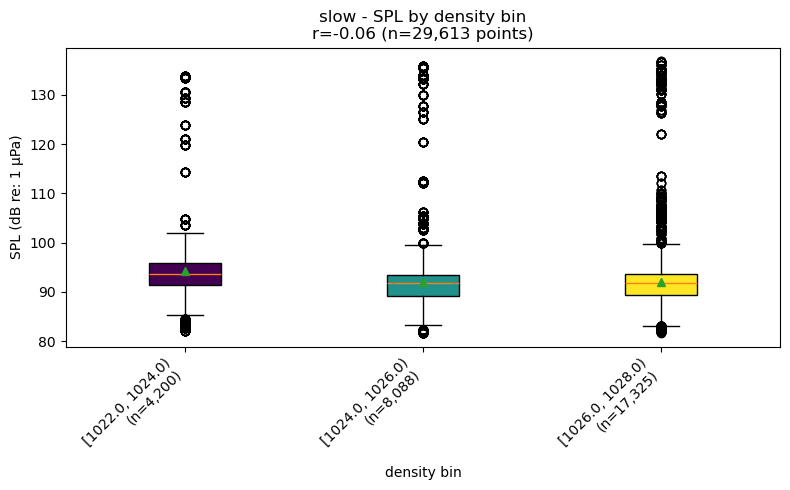

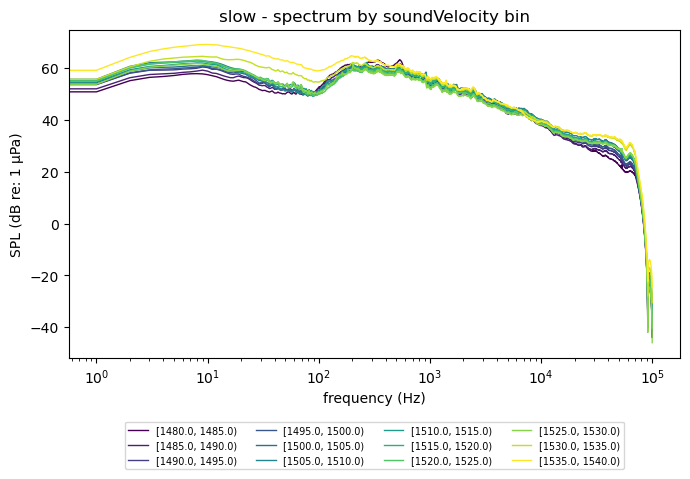

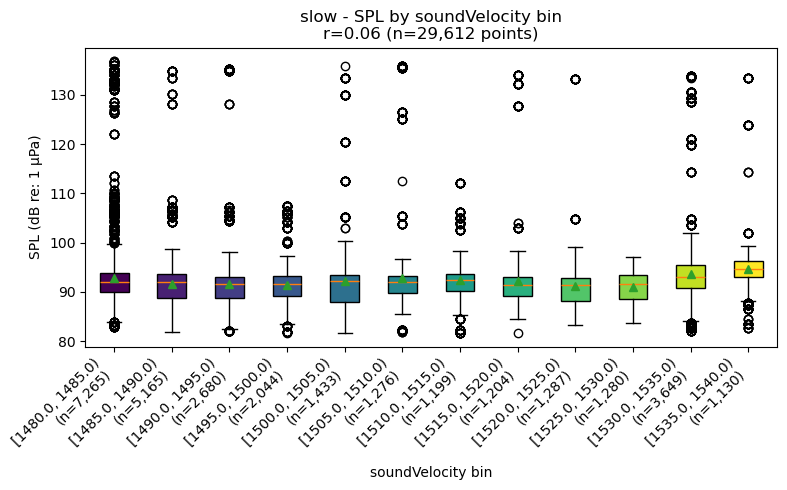

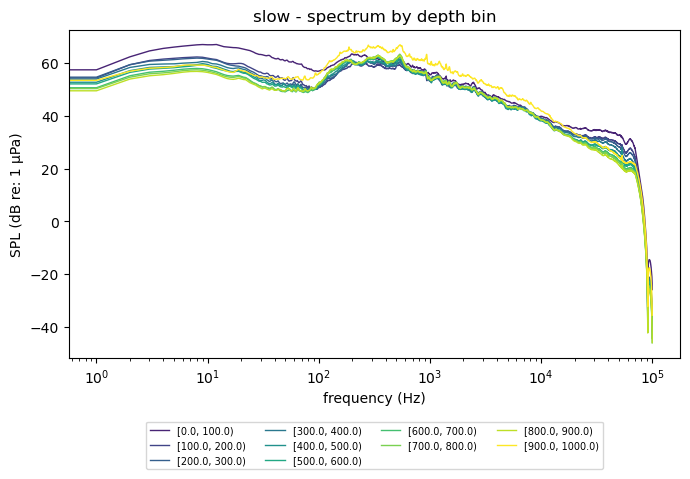

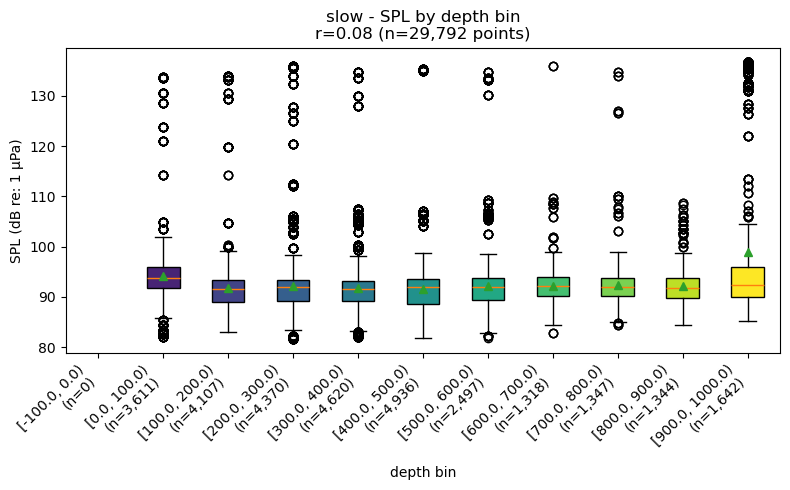

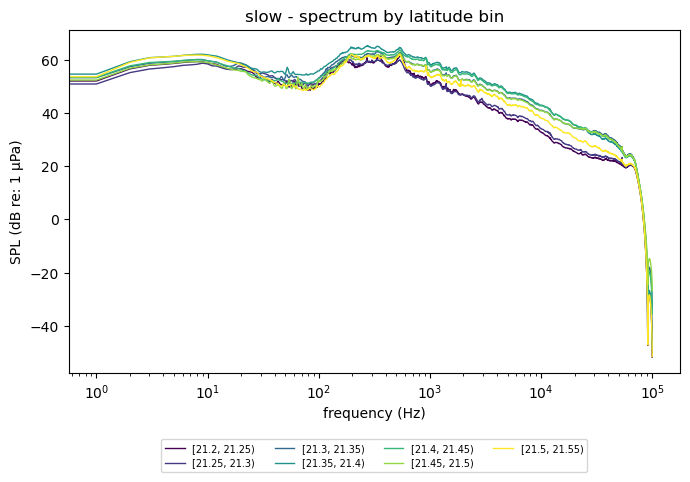

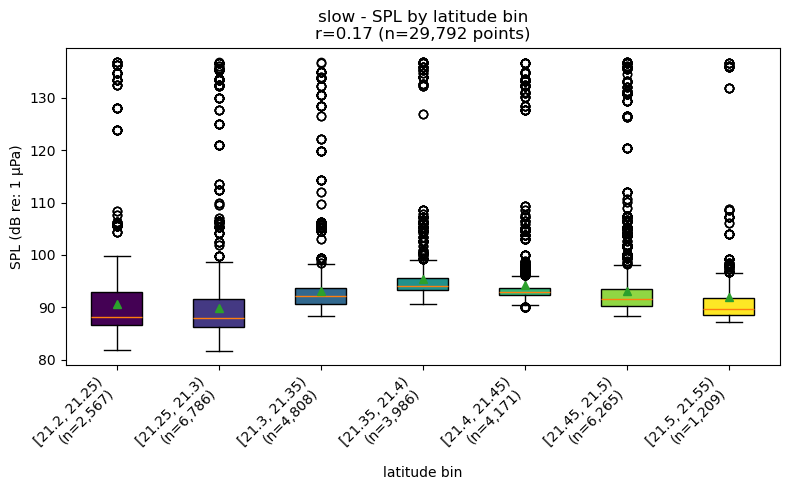

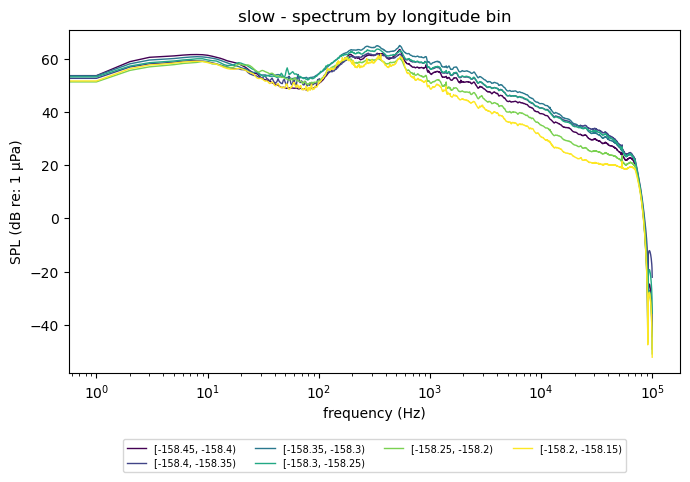

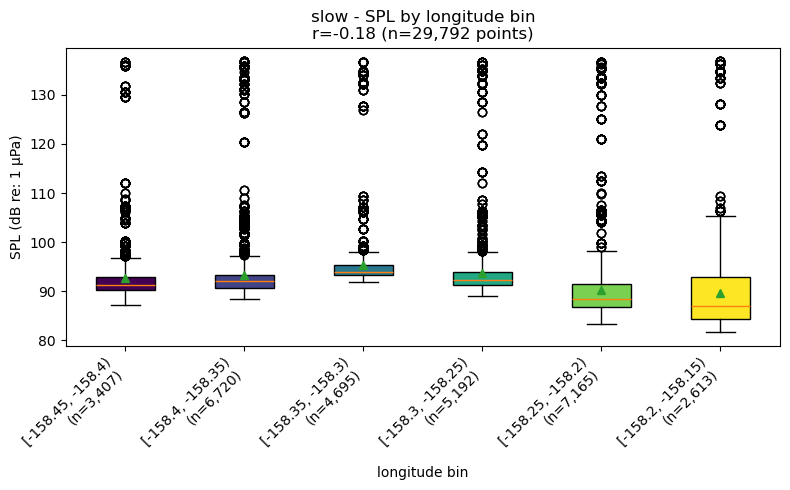

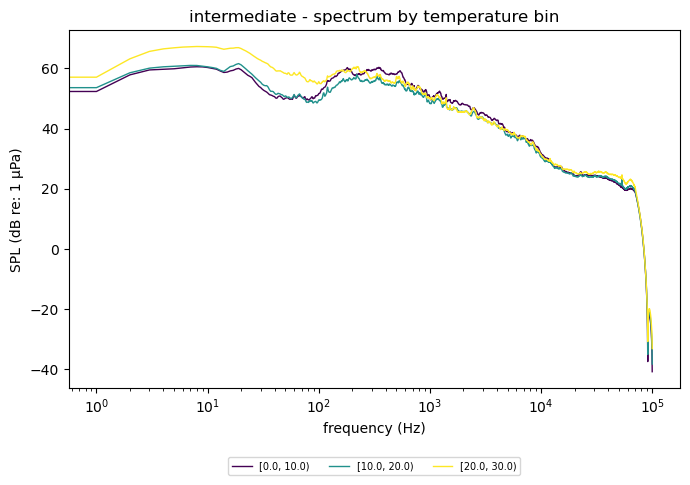

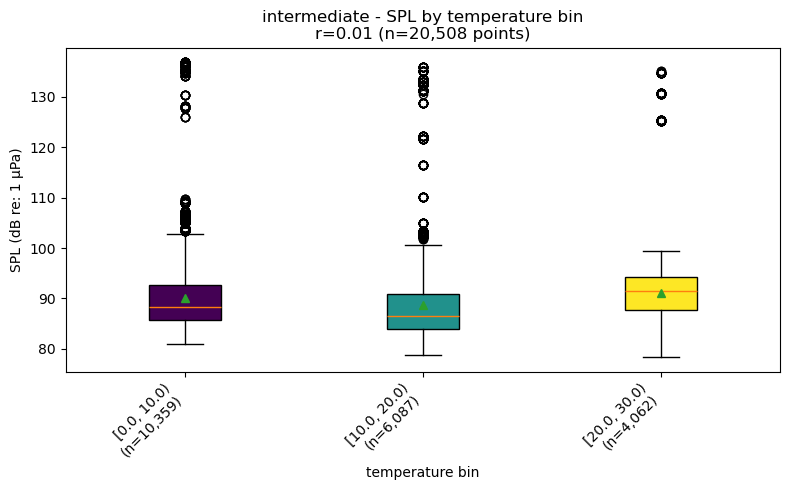

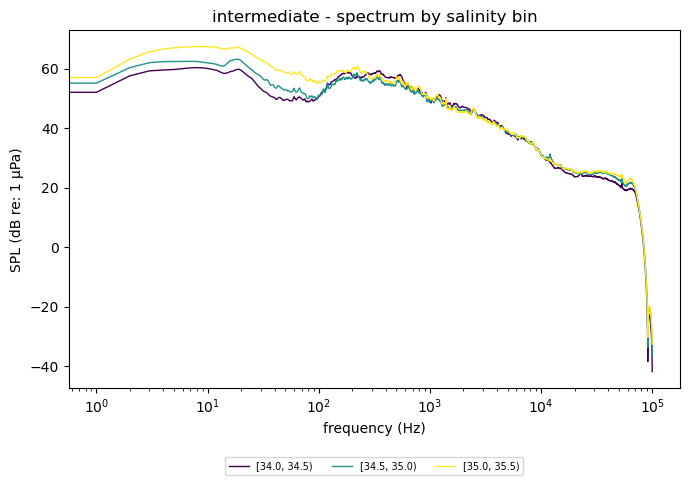

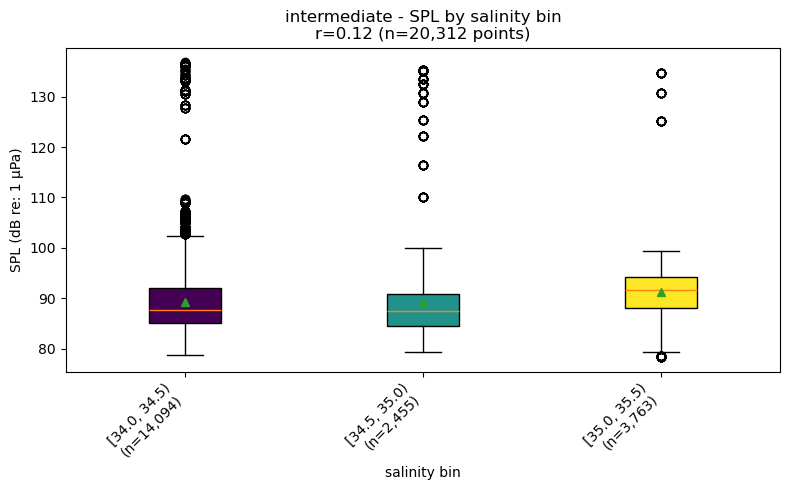

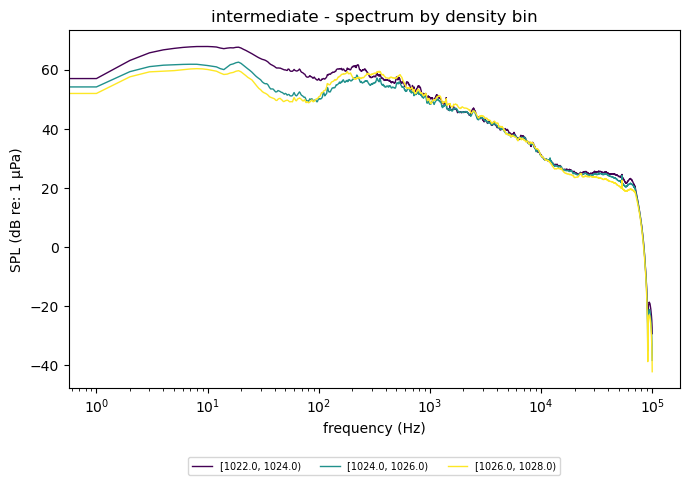

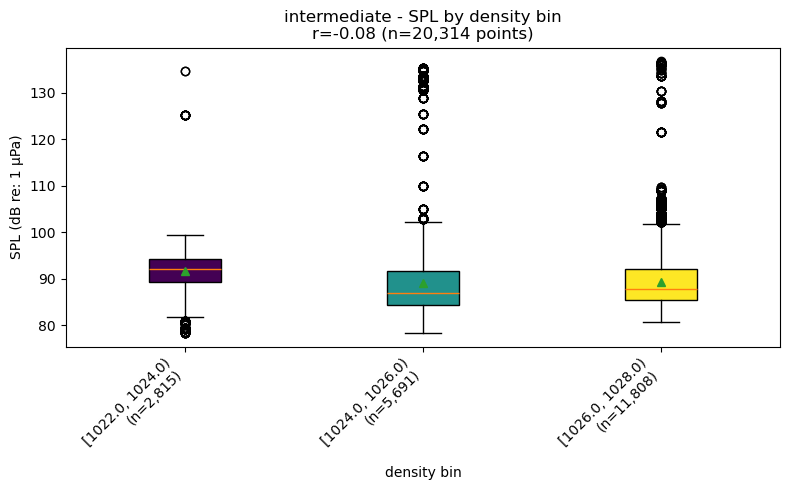

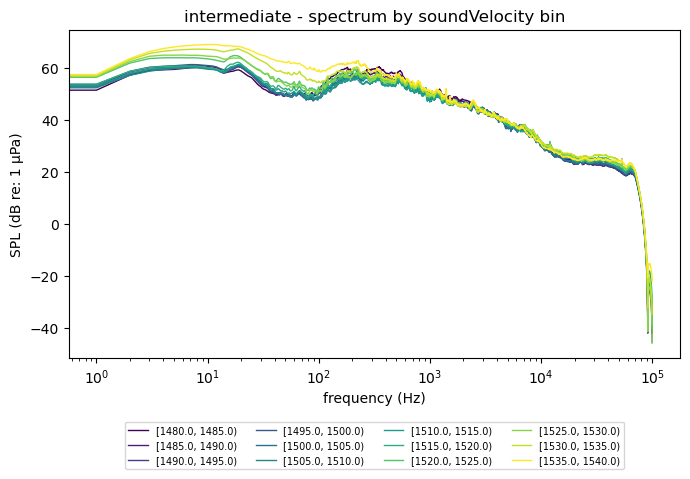

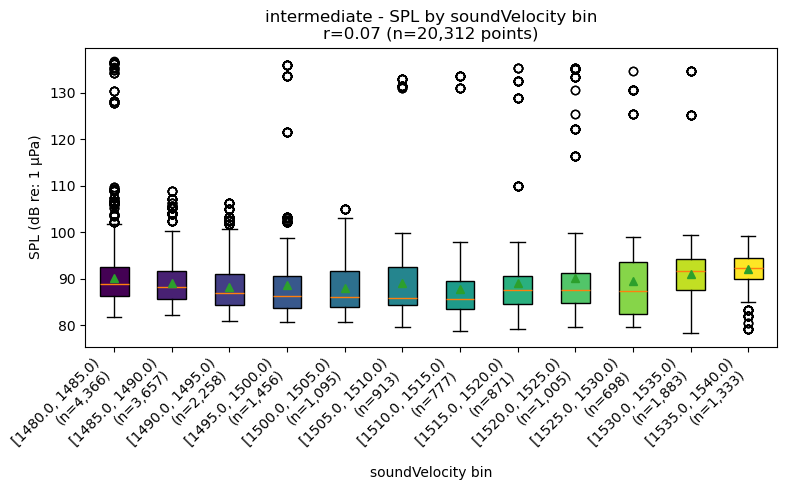

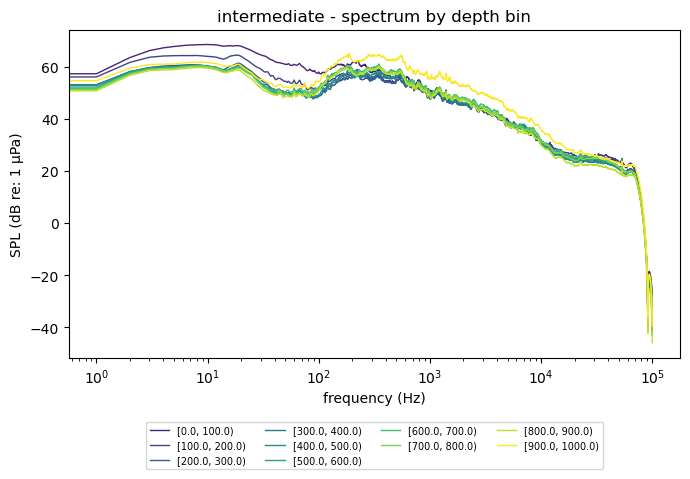

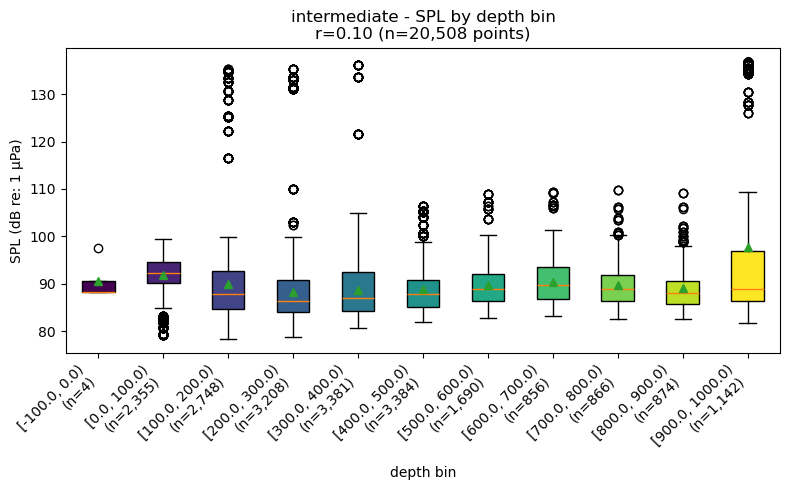

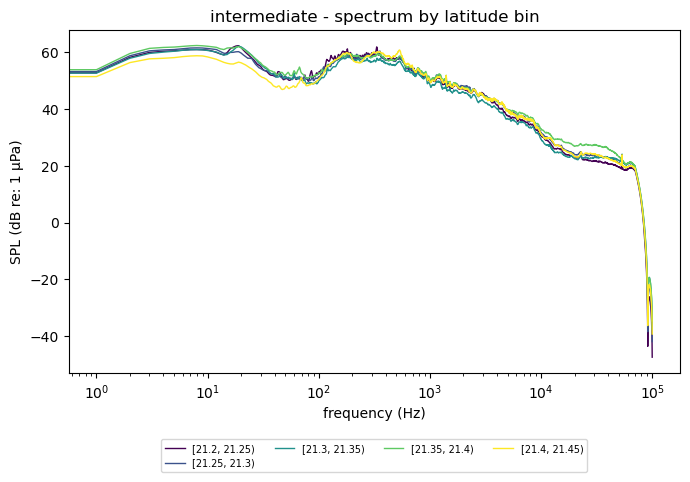

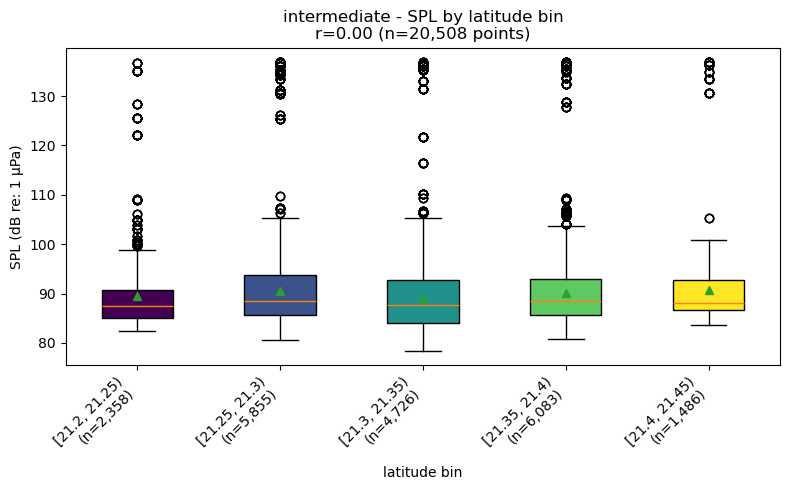

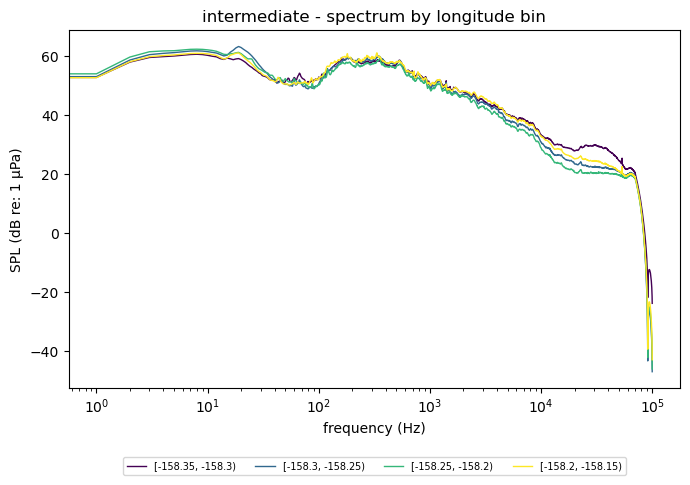

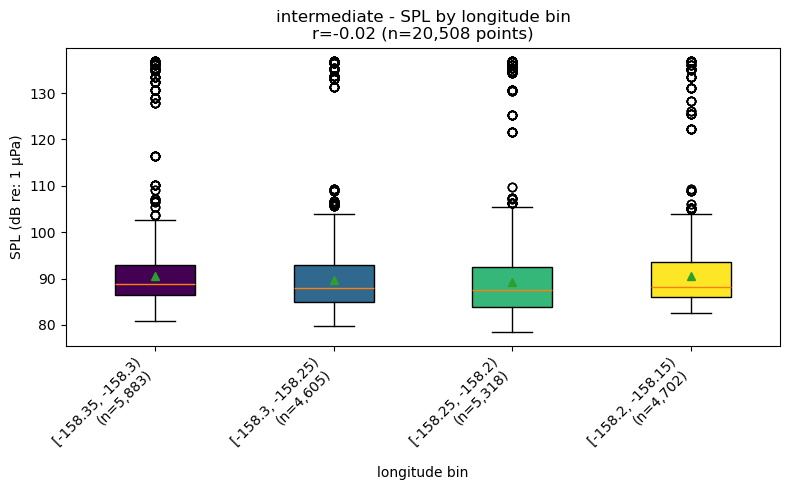

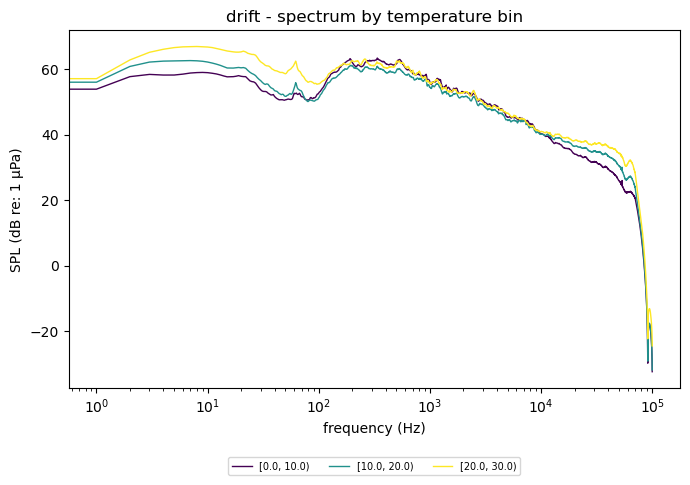

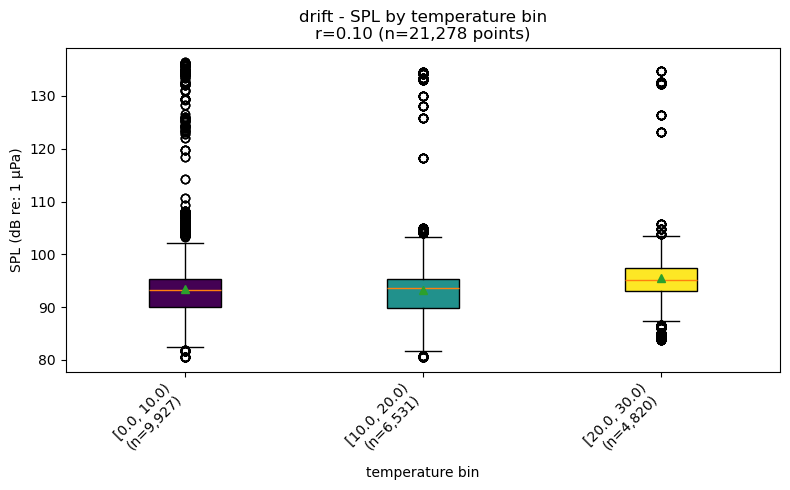

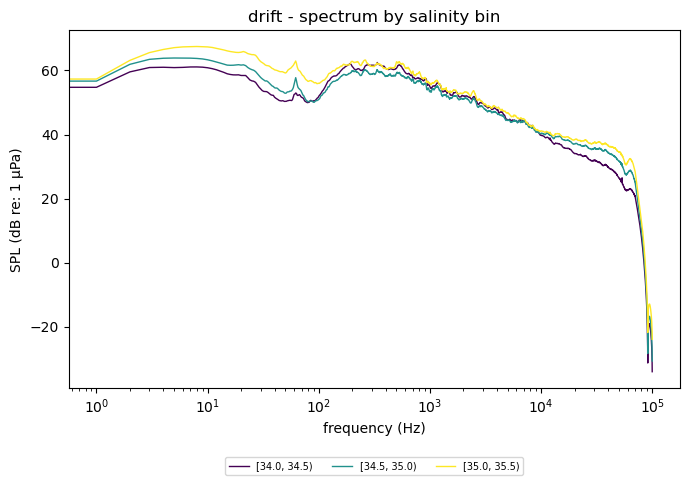

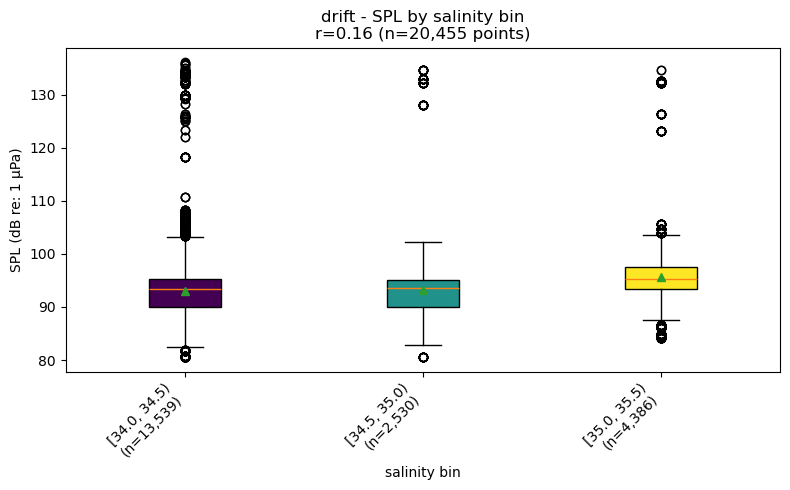

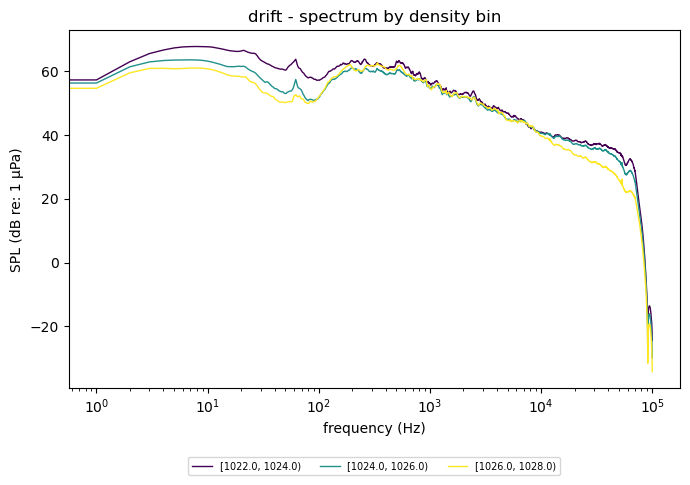

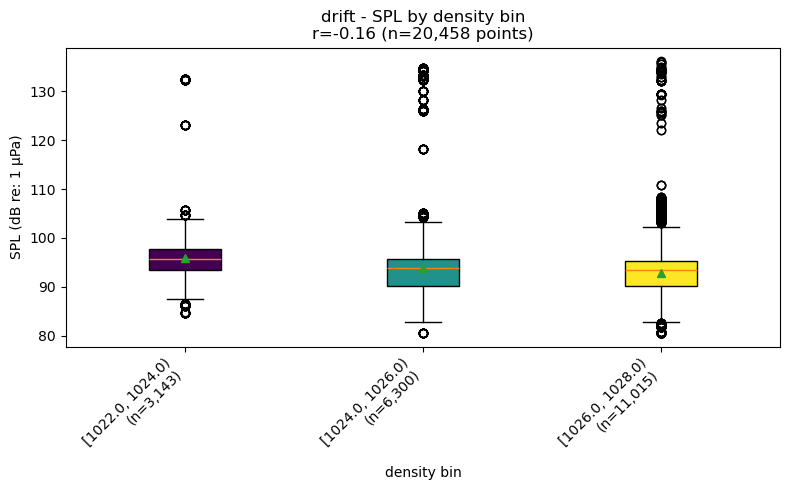

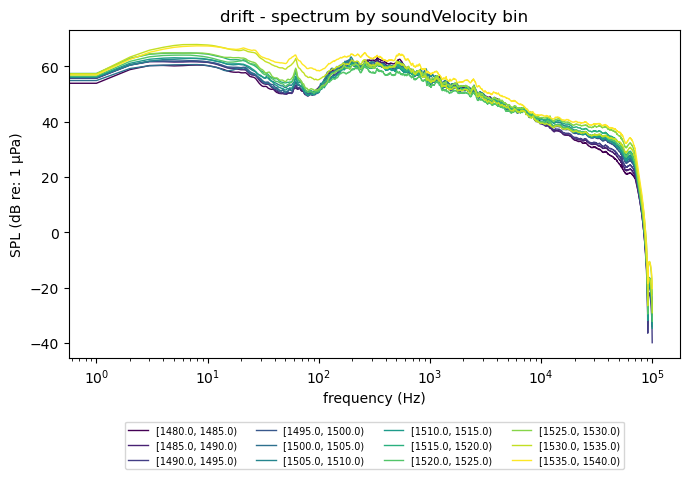

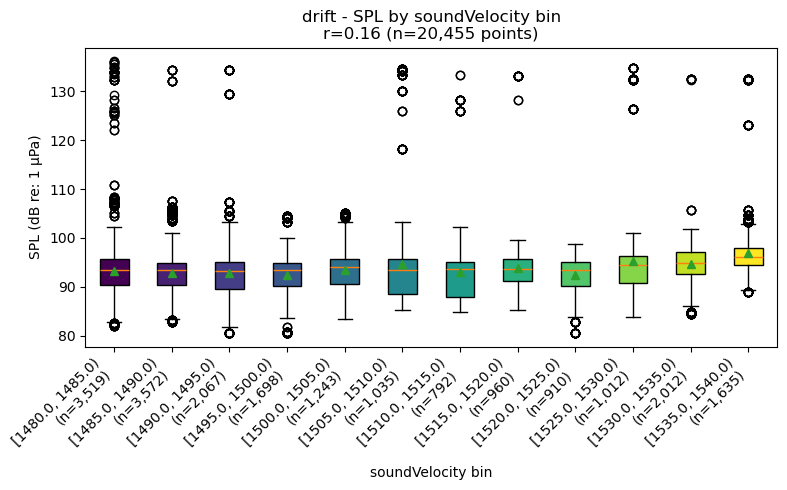

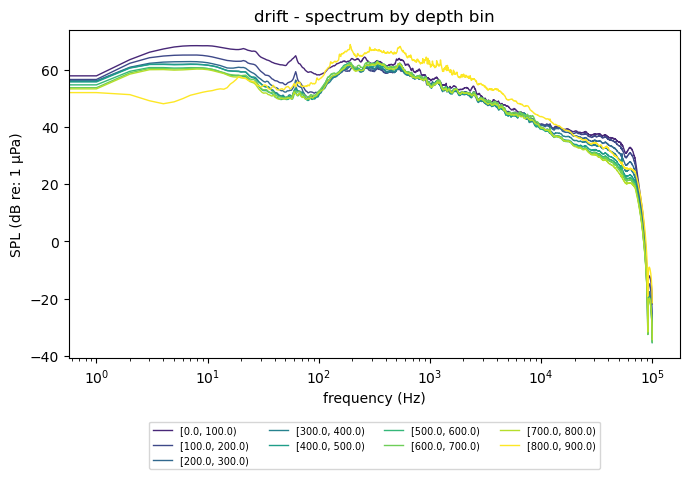

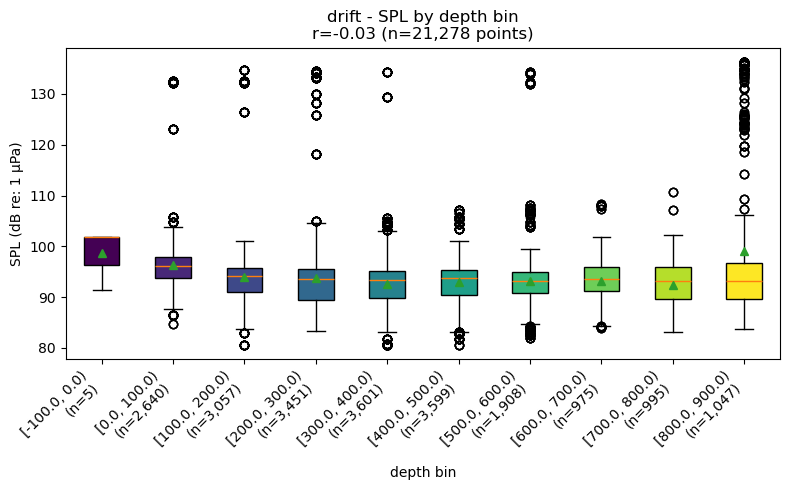

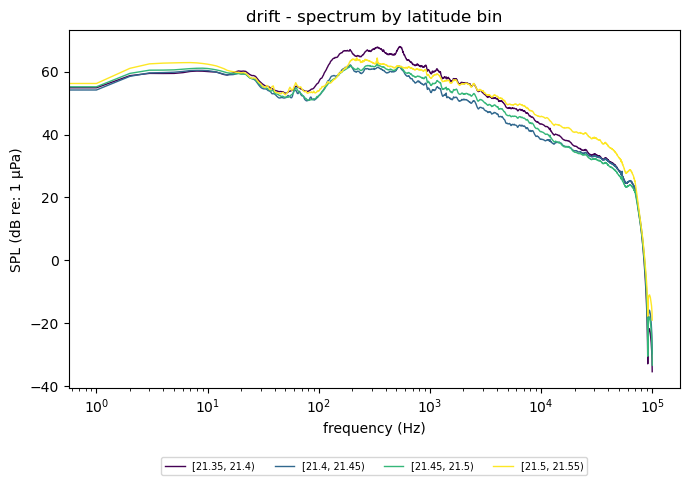

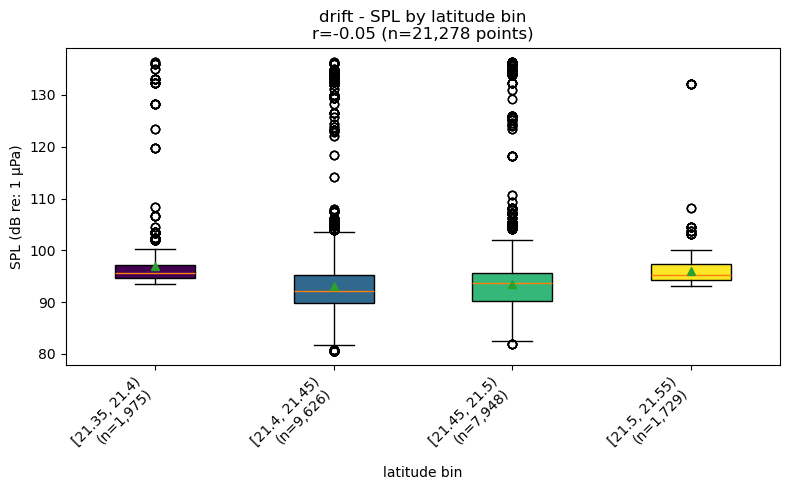

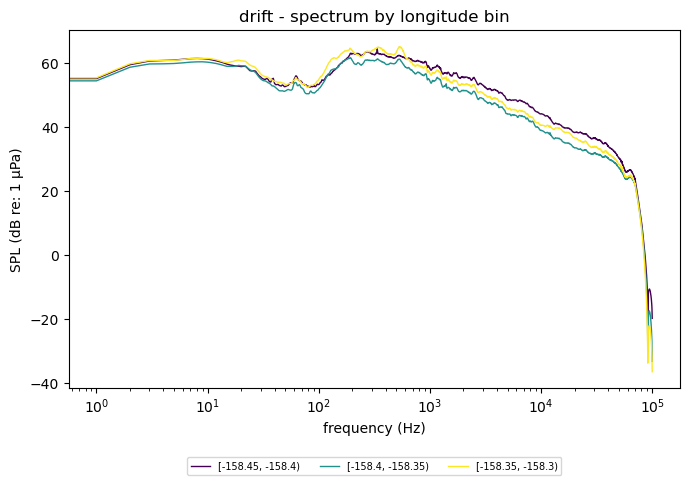

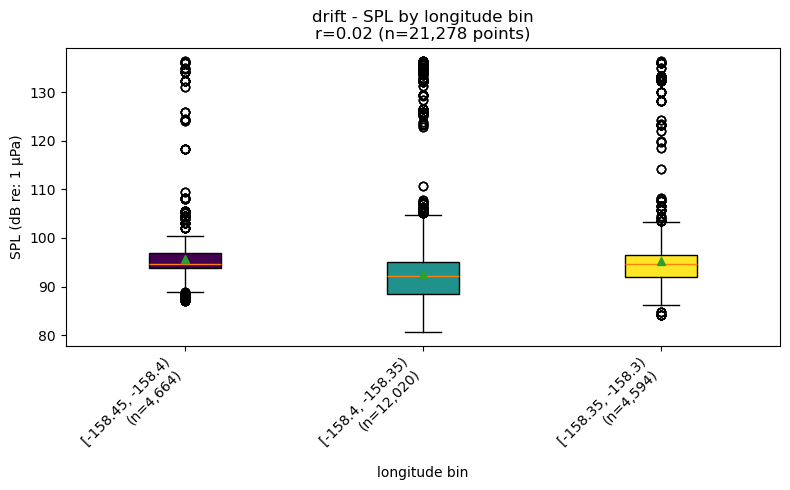

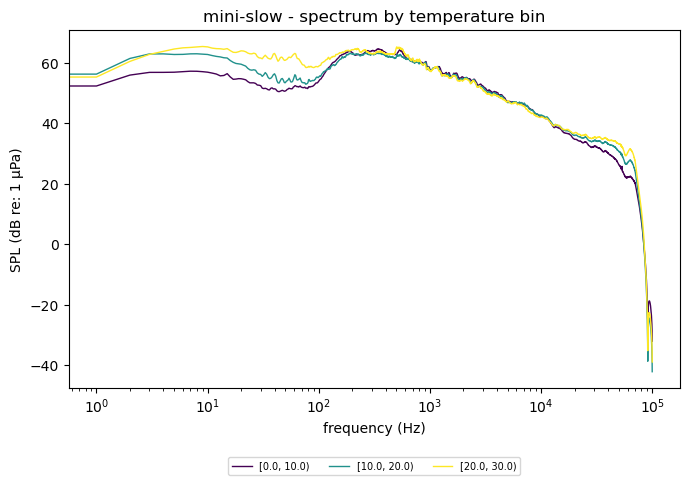

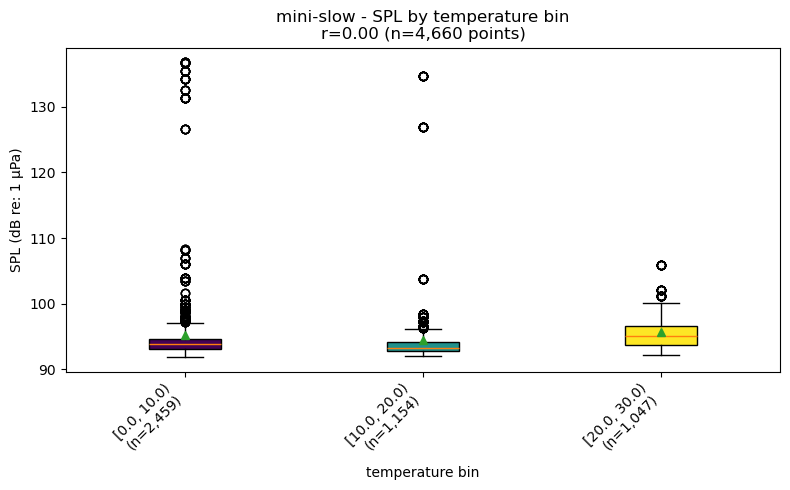

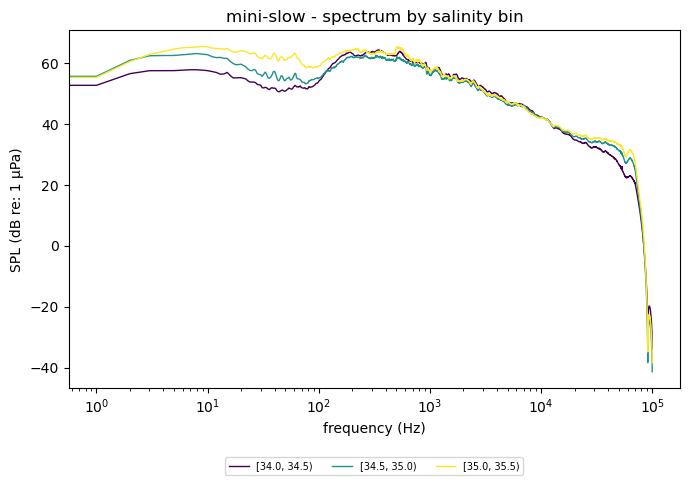

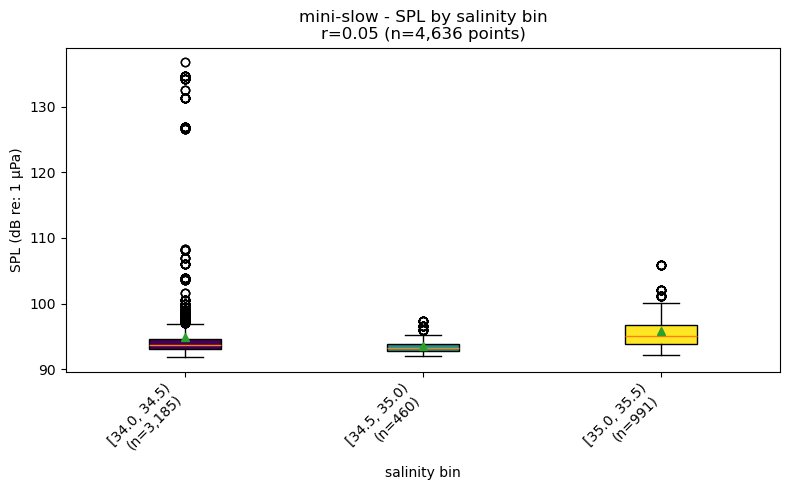

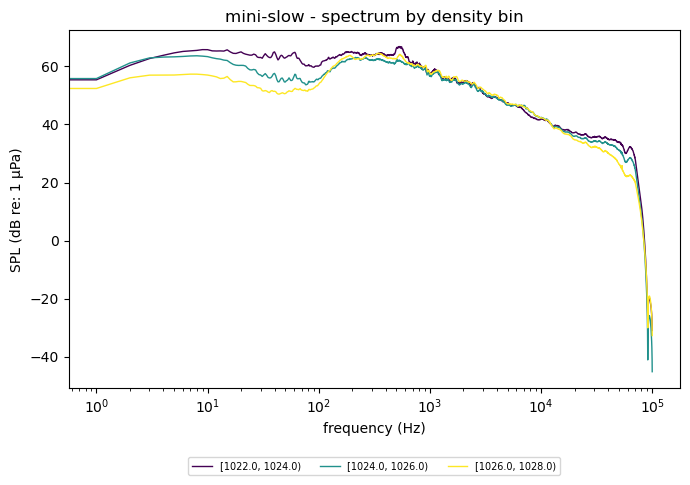

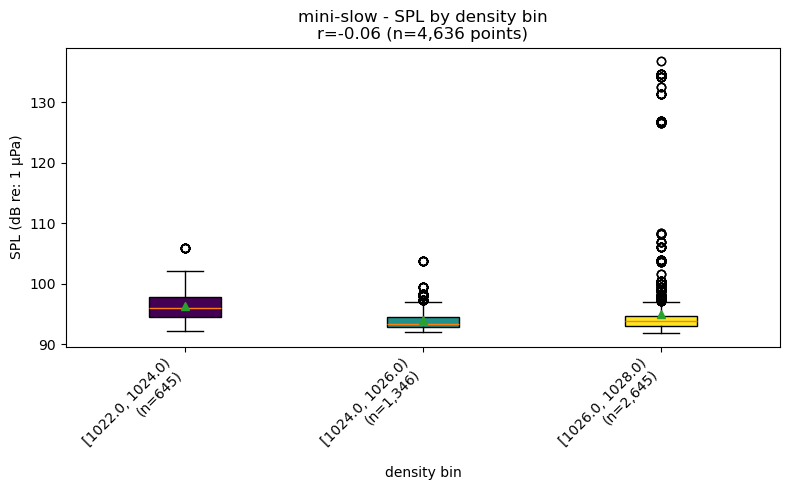

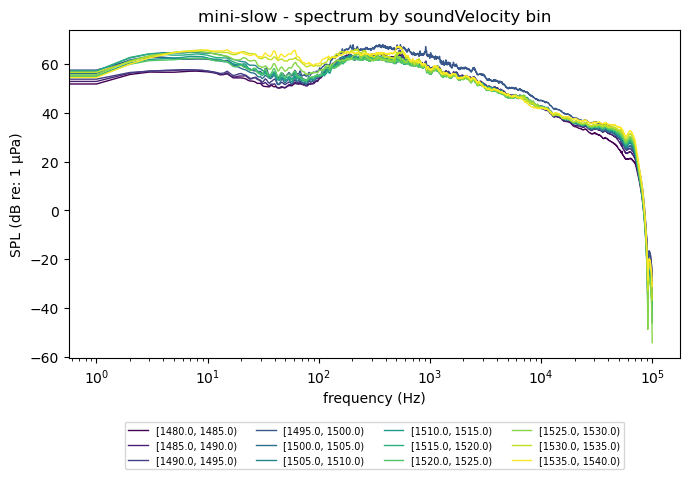

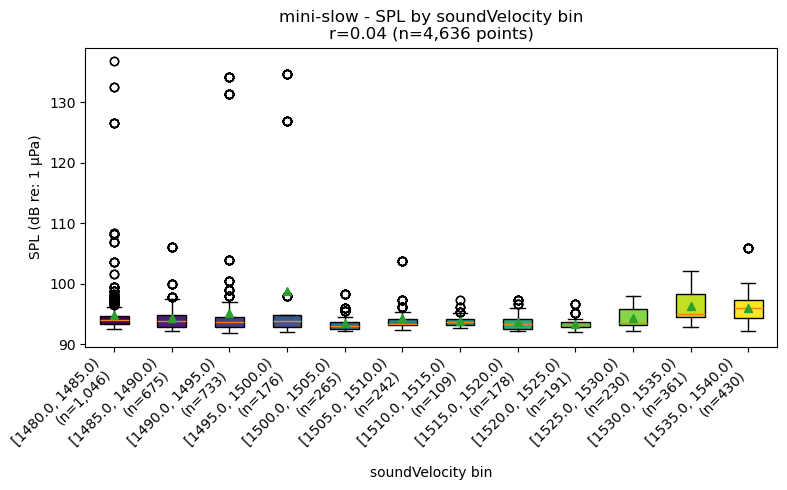

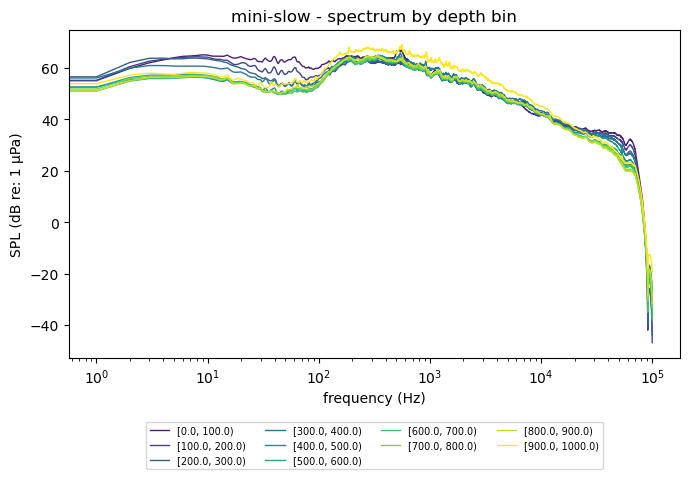

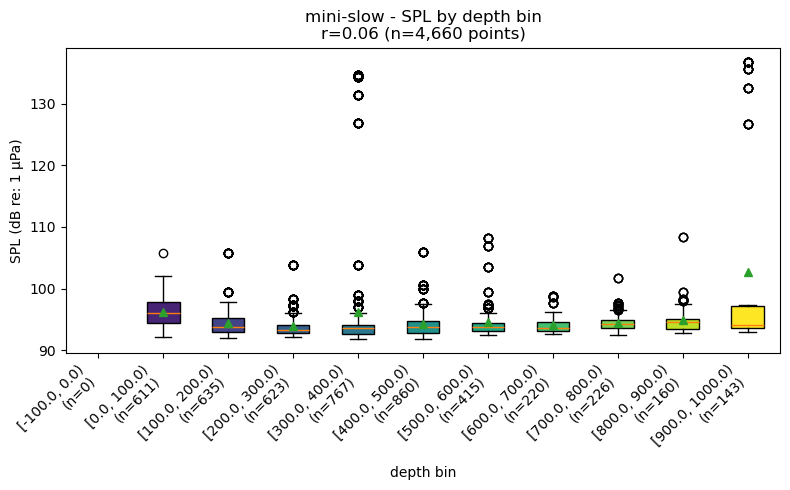

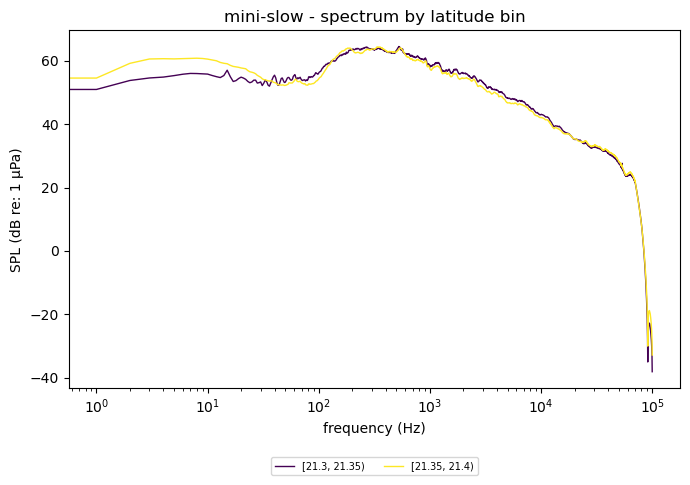

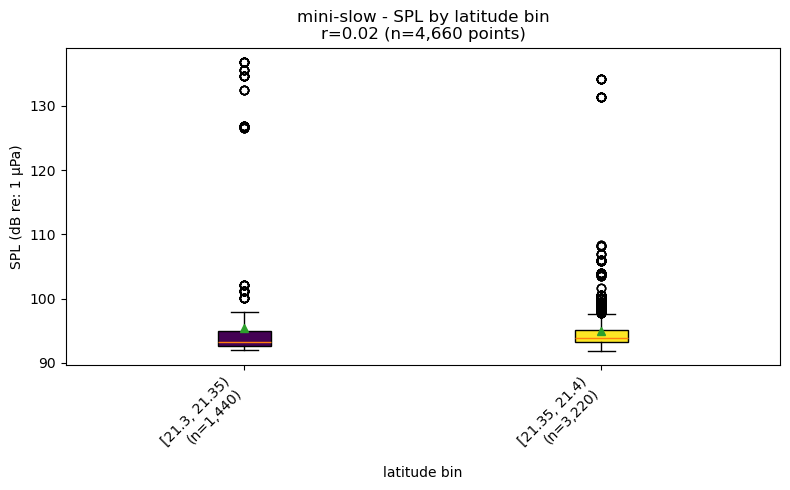

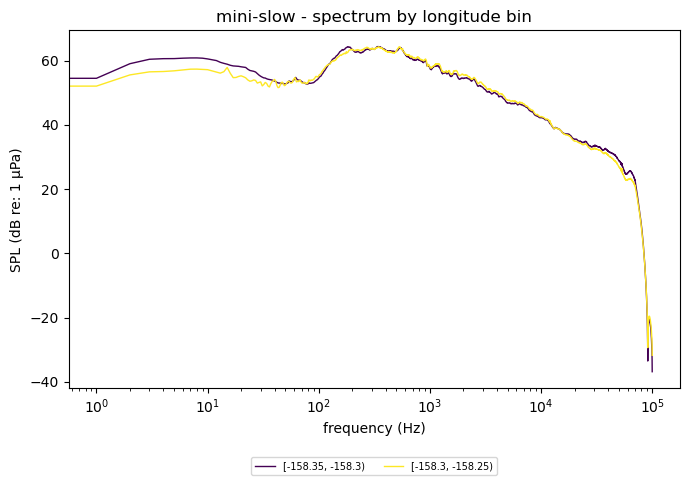

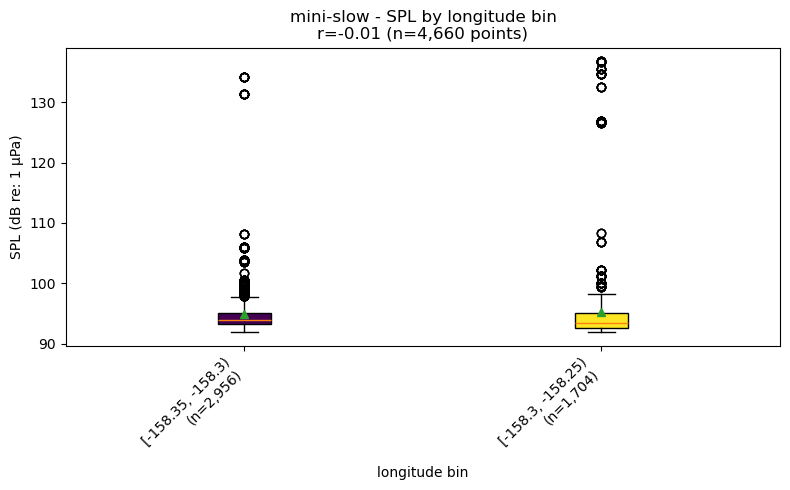

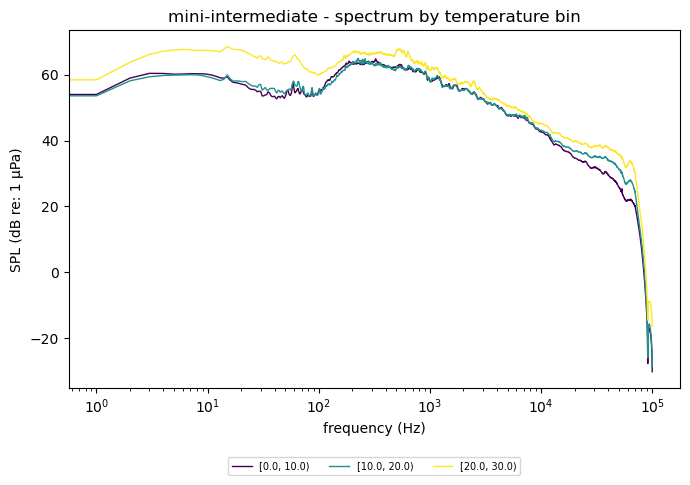

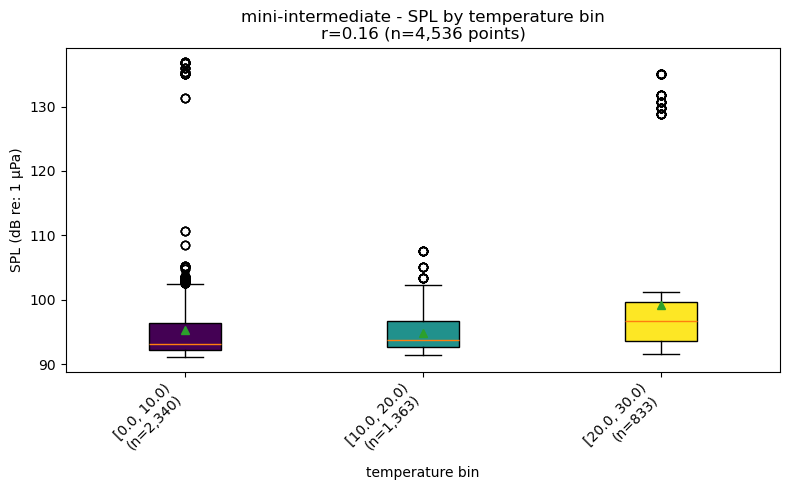

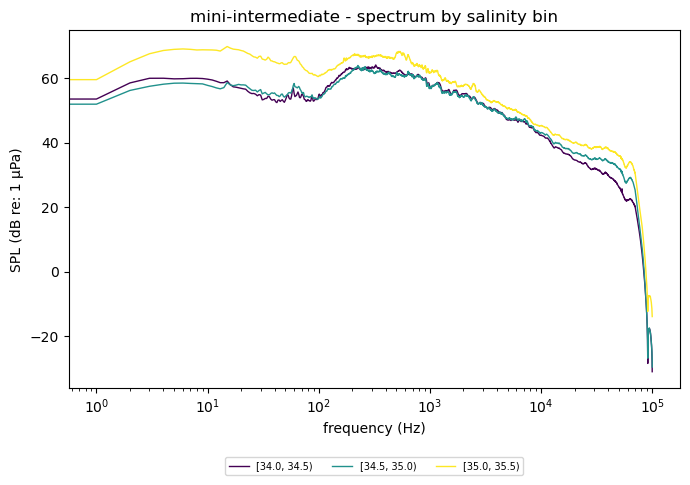

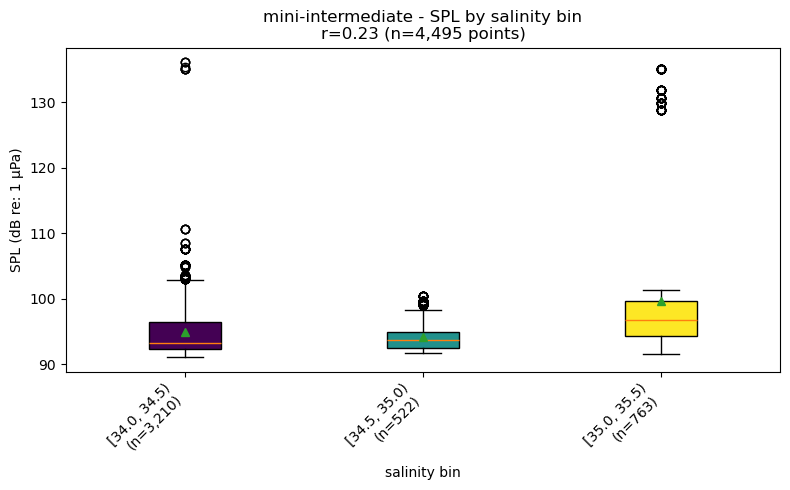

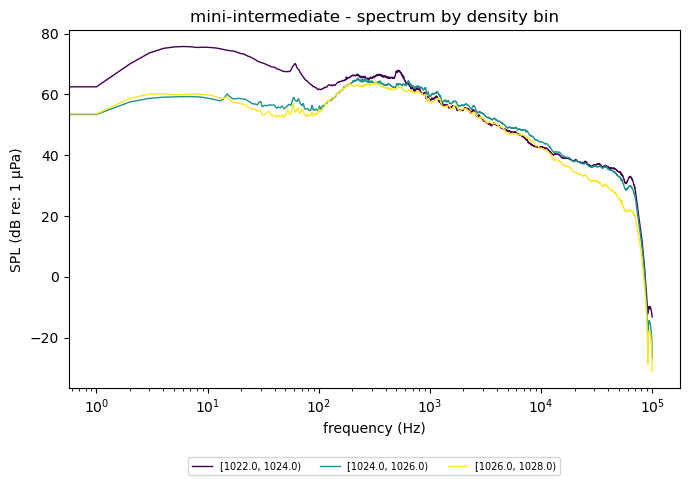

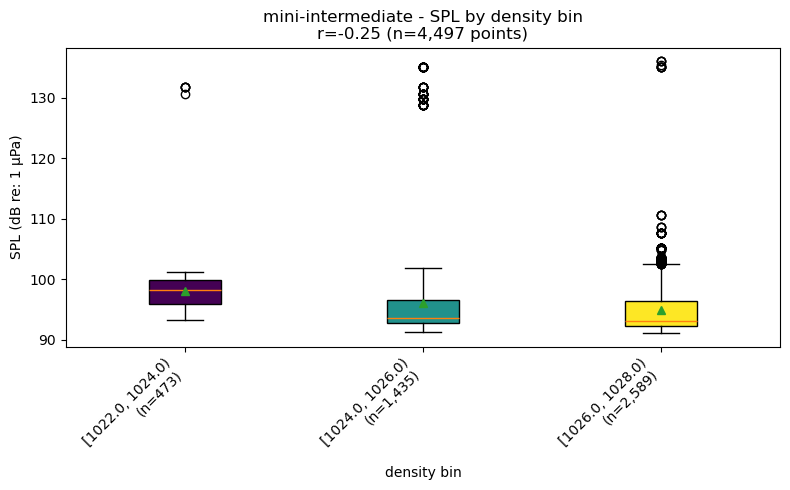

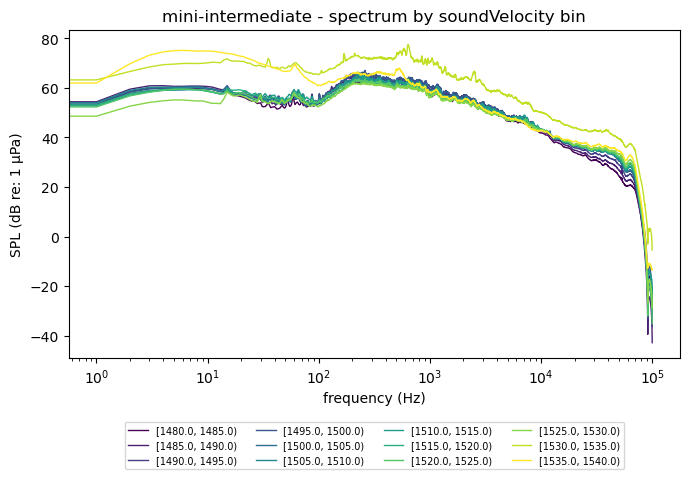

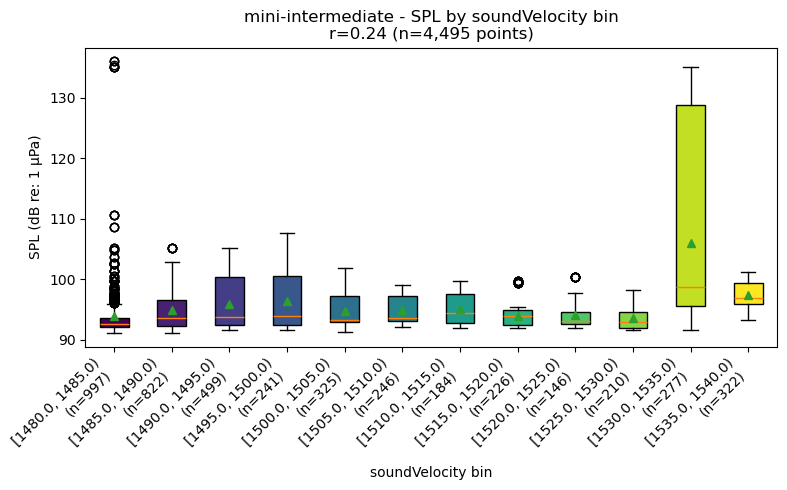

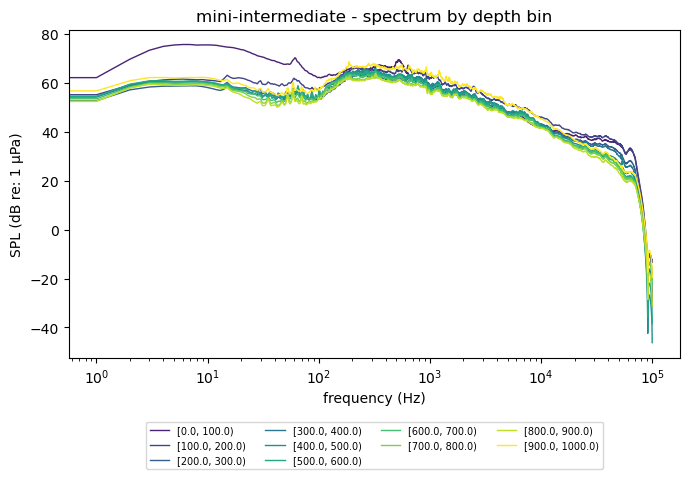

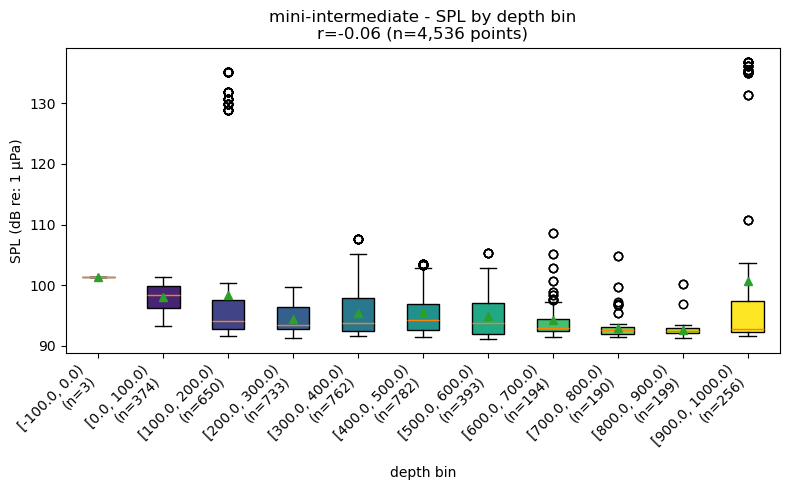

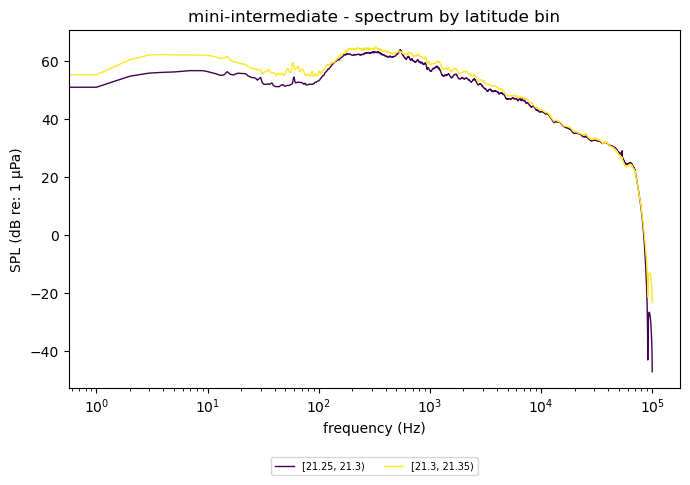

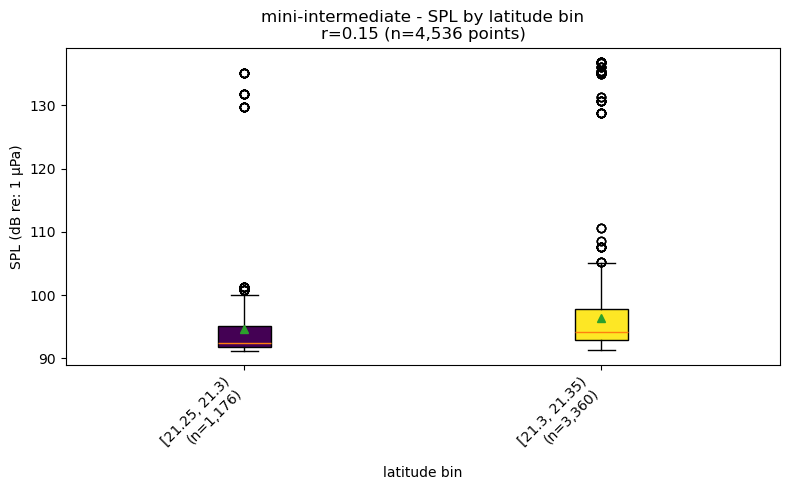

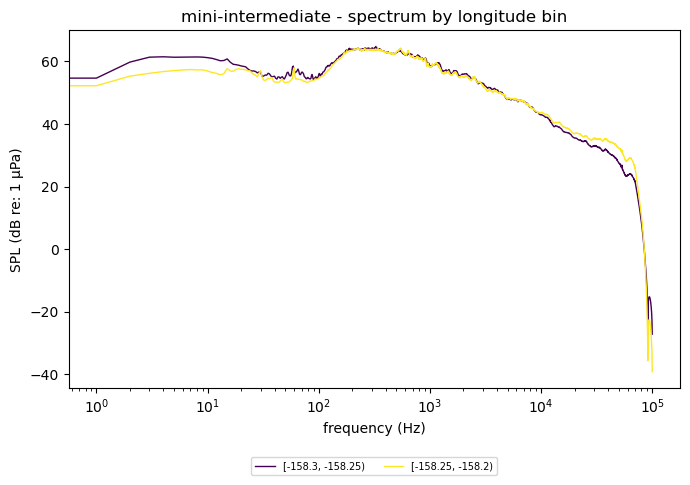

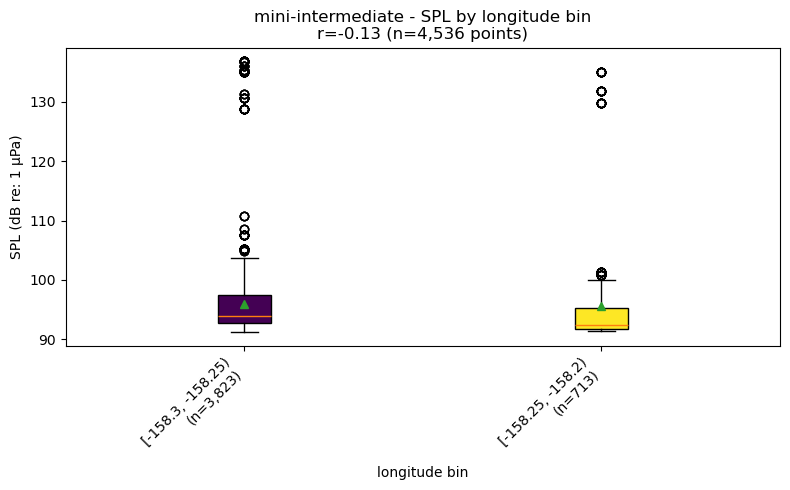

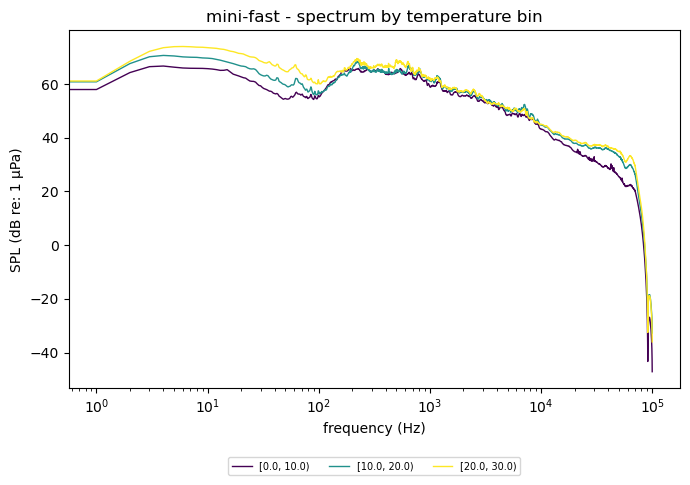

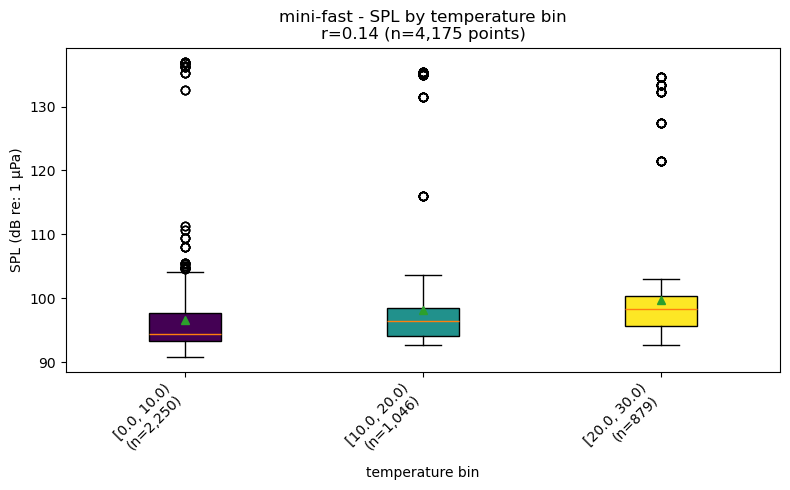

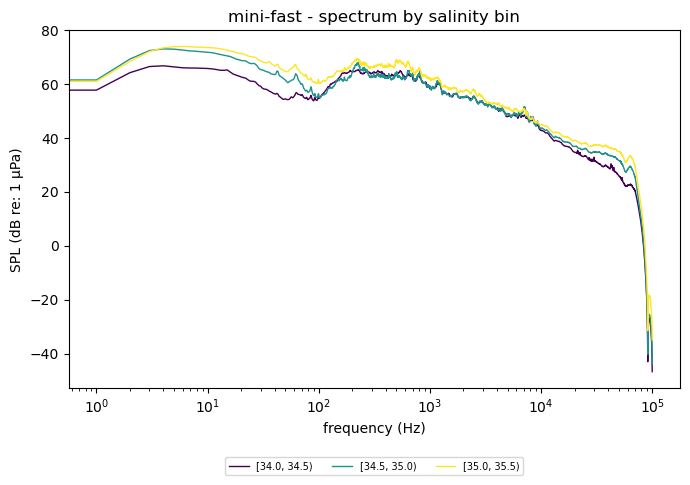

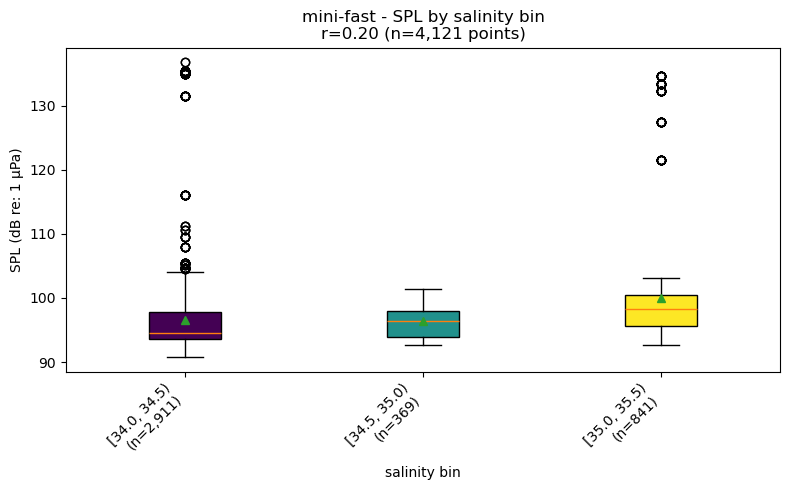

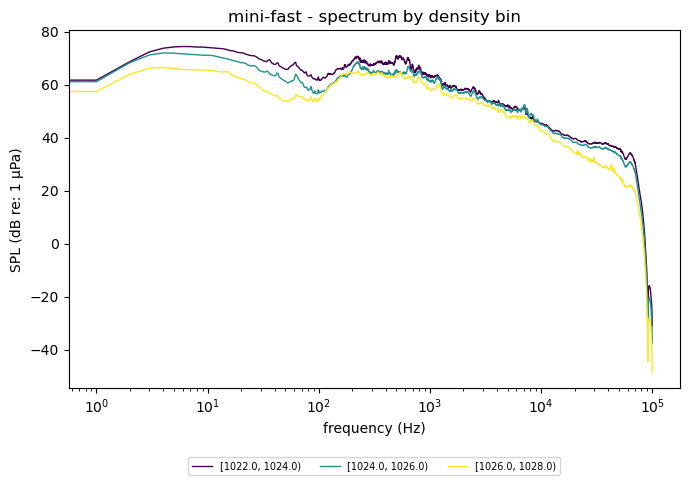

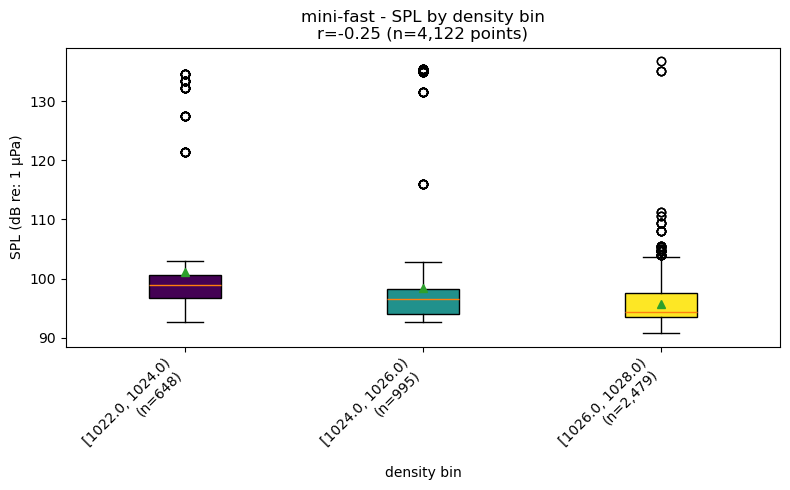

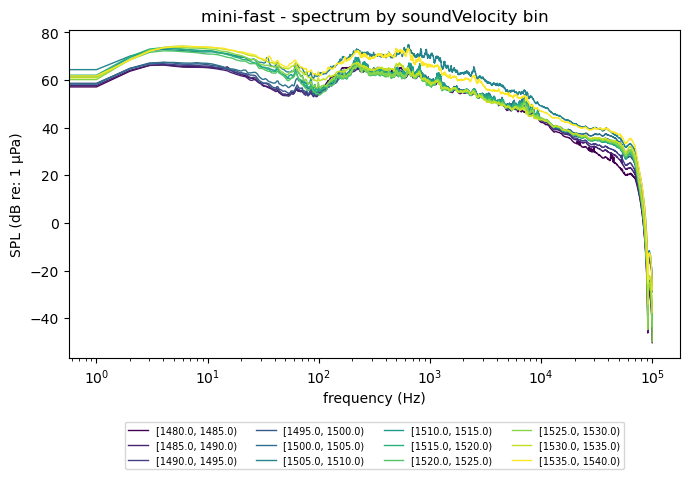

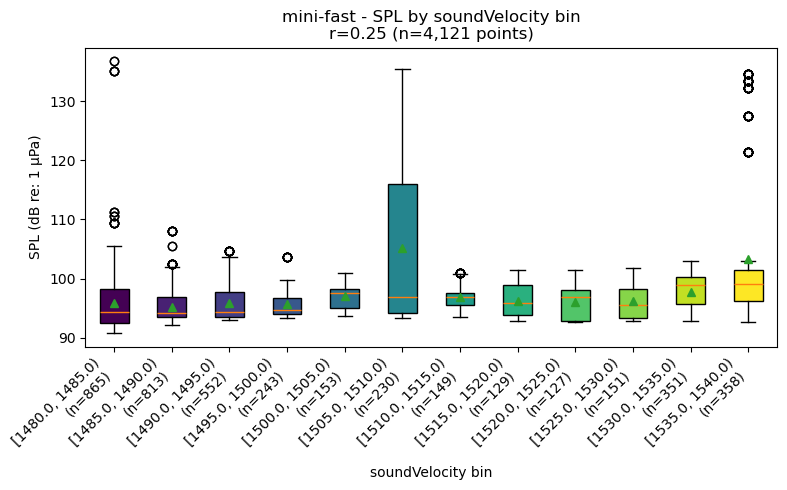

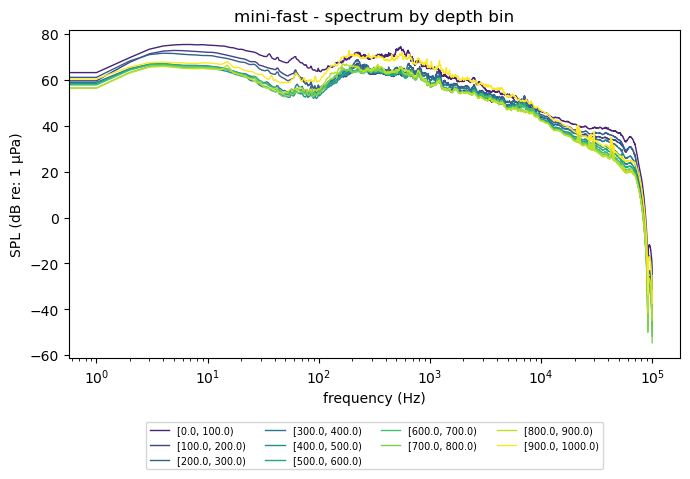

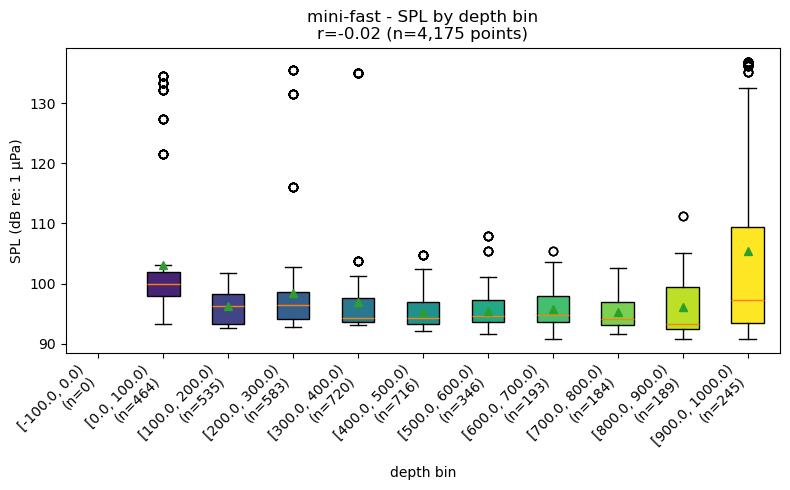

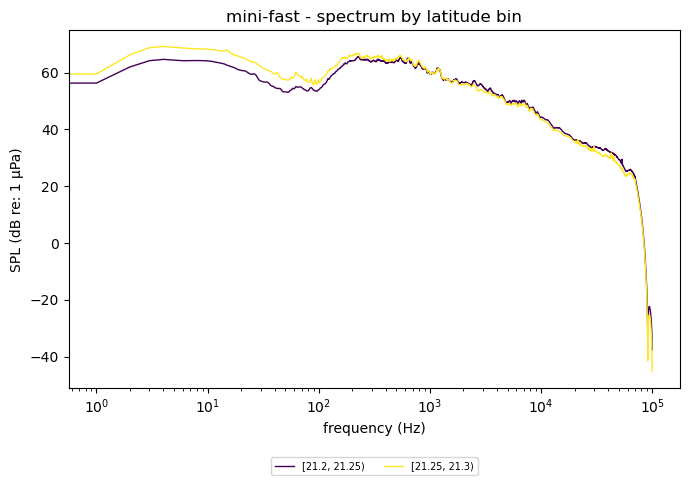

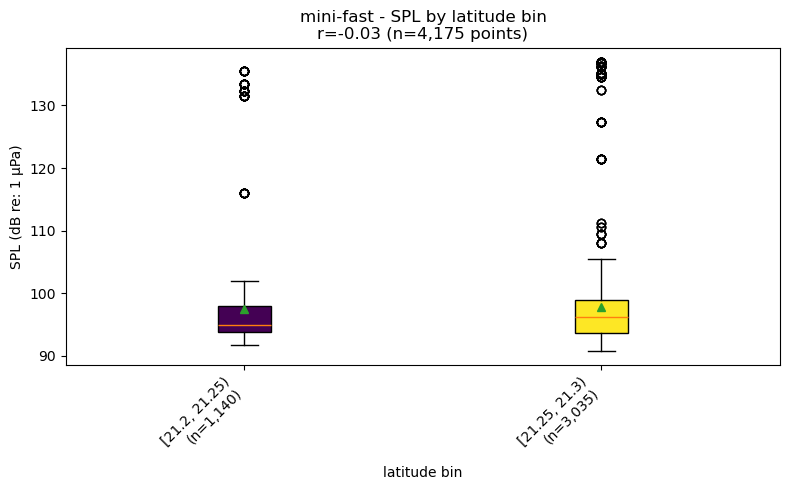

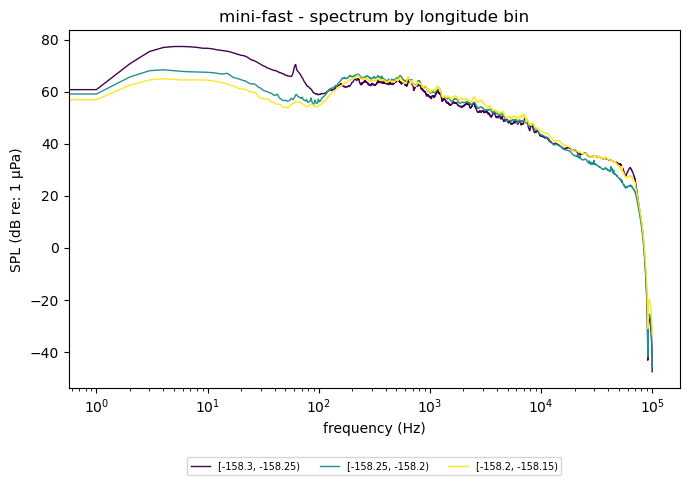

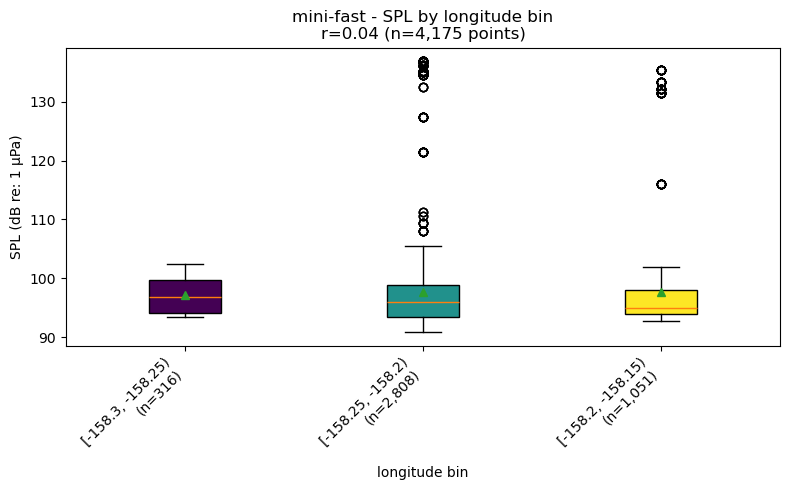

,mode,var,r,p,n
0,shakedown,temperature,0.160369,2.145462e-63,10845
1,shakedown,salinity,0.201496,3.929653e-98,10667
2,shakedown,density,-0.192222,1.874173e-89,10684
3,shakedown,soundVelocity,0.184389,3.262415e-82,10667
4,shakedown,depth,-0.117741,8.739810e-35,10845
...,...,...,...,...,...
58,mini-fast,density,-0.254822,4.185250e-62,4122
59,mini-fast,soundVelocity,0.248320,5.901385e-59,4121
60,mini-fast,depth,-0.023306,1.321580e-01,4175
61,mini-fast,latitude,-0.033370,3.107343e-02,4175


In [12]:
# Per (mode, var): spectrum-by-bin (x=frequency log-scale, y=SPL, one line per bin) and
# box-by-bin (x=bin, y=SPL, no legend). The correlation reported here is a real per-point
# Pearson r between the raw variable and raw broadband SPL across every row in that mode
# (not aggregated into bins) - a statistically meaningful number, unlike correlating bin
# midpoints against bin means (which only has as many points as there are bins).
mode_var_plots = {}    # {(mode, var): {'spectrum': path, 'box': path}}
bin_corr = []           # rows: mode, var, r, p, n

bin_cmap = plt.get_cmap('viridis')

for mode in mode_order:
    mode_pam = pam_labeled[pam_labeled['phase'] == mode]
    mode_glider = glider_sci_df[glider_sci_df['phase'] == mode]

    for var in BIN_VARS:
        bin_col = f'{var}_bin'
        bins_in_mode = sorted(mode_glider[bin_col].dropna().unique(), key=lambda iv: iv.left)
        if not bins_in_mode:
            continue
        bin_colors = {b: bin_cmap(i / max(len(bins_in_mode) - 1, 1)) for i, b in enumerate(bins_in_mode)}

        # --- real per-point correlation: raw var vs raw broadband, every row in this mode ---
        raw = mode_glider[[var, 'broadband']].dropna()
        if len(raw) >= 2:
            r, p = stats.pearsonr(raw[var], raw['broadband'])
        else:
            r, p = np.nan, np.nan
        bin_corr.append({'mode': mode, 'var': var, 'r': r, 'p': p, 'n': len(raw)})

        # --- spectrum: one line per bin, x=frequency (log), y=SPL ---
        spectrum_by_bin = {}
        for b in bins_in_mode:
            bsub = mode_pam[mode_pam[bin_col] == b]
            if bsub.empty:
                continue
            spectrum_by_bin[b] = bsub[hybrid_cols].mean().values

        fig, ax = plt.subplots(figsize=(7, 5))
        plot_spectrum_lines(hybrid_freqs, spectrum_by_bin, bin_colors, f'{mode} - spectrum by {var} bin', ax=ax)
        plt.tight_layout()
        spectrum_fname = os.path.join(FIGURES_DIR, f'{glider_id}_spectrum_{mode}_{var}.png'.replace(' ', '_'))
        fig.savefig(spectrum_fname, dpi=150, bbox_inches='tight')
        plt.show()

        # --- box: x = bin, y = SPL, no legend ---
        box_by_bin = {b: mode_glider.loc[mode_glider[bin_col] == b, 'broadband'].dropna() for b in bins_in_mode}

        title = f'{mode} - SPL by {var} bin'
        if not np.isnan(r):
            title += f'\nr={r:.2f} (n={len(raw):,} points)'

        fig, ax = plt.subplots(figsize=(8, 5))
        plot_box_by_group(box_by_bin, bin_colors, f'{var} bin', 'SPL (dB re: 1 μPa)', title, ax=ax)
        plt.tight_layout()
        box_fname = os.path.join(FIGURES_DIR, f'{glider_id}_box_{mode}_{var}.png'.replace(' ', '_'))
        fig.savefig(box_fname, dpi=150, bbox_inches='tight')
        plt.show()

        mode_var_plots[(mode, var)] = {'spectrum': spectrum_fname, 'box': box_fname}

bin_corr_df = pd.DataFrame(bin_corr)
bin_corr_df

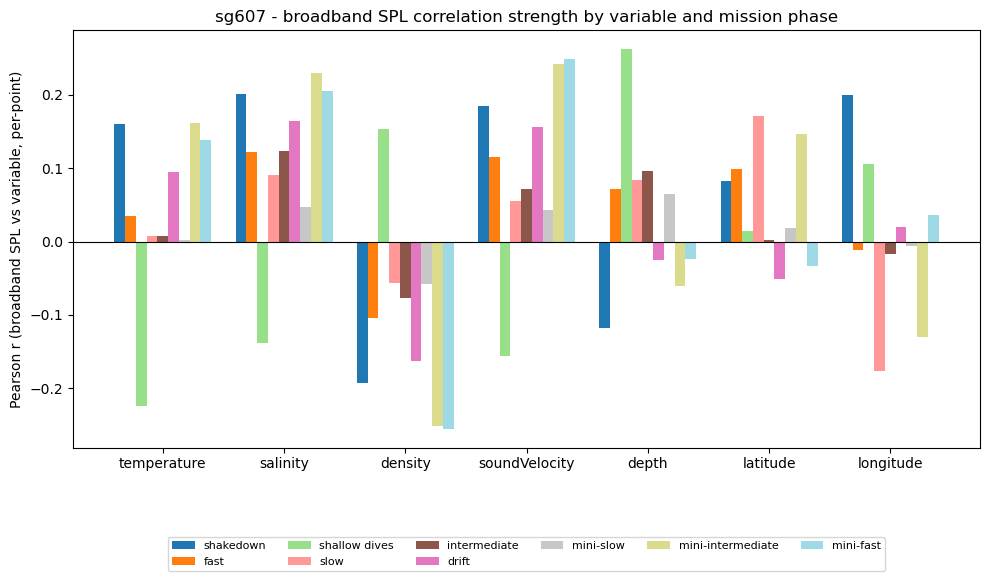

In [13]:
# Correlation strength (real per-point Pearson r between raw variable and raw broadband SPL)
# per variable, grouped by mode
pivot = bin_corr_df.pivot(index='var', columns='mode', values='r').reindex(index=BIN_VARS, columns=mode_order)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pivot.index))
width = 0.8 / len(mode_order)
for i, mode in enumerate(mode_order):
    ax.bar(x + i * width, pivot[mode], width=width, color=mode_colors[mode], label=mode)

ax.set_xticks(x + width * (len(mode_order) - 1) / 2)
ax.set_xticklabels(pivot.index)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_ylabel('Pearson r (broadband SPL vs variable, per-point)')
ax.set_title(f'{glider_id} - broadband SPL correlation strength by variable and mission phase')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=6, fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f'{glider_id}_broadband_correlation_by_mode.png'), dpi=150, bbox_inches='tight')
plt.show()

## Export results for the presentation notebook

All the PNGs above are already saved to `FIGURES_DIR` by each plotting cell. This just saves
the small tabular/summary results (`bin_corr_df`, the plot-path lookup, and a few headline
numbers) to `DATA_DIR`, which `glider_noise_presentation.ipynb` reads to assemble the deck.

In [14]:
overall_corr_df.to_csv(os.path.join(DATA_DIR, f'{glider_id}_overall_corr.csv'), index=False)
bin_corr_df.to_csv(os.path.join(DATA_DIR, f'{glider_id}_bin_corr.csv'), index=False)
qc_impact_df.to_csv(os.path.join(DATA_DIR, f'{glider_id}_qc_impact.csv'), index=False)

mode_var_records = [
    {'mode': mode, 'var': var, 'spectrum': plots['spectrum'], 'box': plots['box']}
    for (mode, var), plots in mode_var_plots.items()
]
pd.DataFrame(mode_var_records).to_csv(os.path.join(DATA_DIR, f'{glider_id}_mode_var_plots.csv'), index=False)

summary_meta = {
    'glider_id': glider_id,
    'qc_applied': config.QC_APPLIED,
    'mode_order': mode_order,
    'bin_vars': BIN_VARS,
    'n_rows': int(len(glider_sci_df)),
    'mean_broadband': float(glider_sci_df['broadband'].mean()),
    'min_broadband': float(glider_sci_df['broadband'].min()),
    'max_broadband': float(glider_sci_df['broadband'].max()),
}
with open(os.path.join(DATA_DIR, f'{glider_id}_summary_meta.json'), 'w') as f:
    json.dump(summary_meta, f, indent=2)

print(f'Saved {glider_id}_overall_corr.csv, {glider_id}_bin_corr.csv, {glider_id}_qc_impact.csv, '
      f'{glider_id}_mode_var_plots.csv, and {glider_id}_summary_meta.json to {DATA_DIR}/')

Saved sg607_overall_corr.csv, sg607_bin_corr.csv, sg607_qc_impact.csv, sg607_mode_var_plots.csv, and sg607_summary_meta.json to ./noise_analysis_outputs\sg607\data/
